# Density matrices and quantum channels

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 3 — The matrix-free engine*

## 1. Introduction and motivation

Up to now every state in these notes was a **state vector** $|\psi\rangle$: a list of $2^N$ complex amplitudes that
evolves by the Schrödinger equation. That description assumes two things that are never exactly true in a laboratory:

1. **We know which state was prepared.** Real sources are imperfect. An oven, a laser pulse with fluctuating
   intensity, or a qubit that was reset with 98 % success all produce *this* state sometimes and *that* state at other times.
2. **The system is isolated.** A superconducting qubit leaks microwave photons into its wiring (energy relaxation,
   time scale $T_1$); fluctuating magnetic fields scramble the phase of a trapped-ion qubit (dephasing, time scale $T_2$).
   The qubits become *entangled with an environment that we do not track*.

In both situations no single state vector describes the system, and quantum mechanics needs a more general
object: the **density operator** (density matrix) $\rho$. Noise then acts on $\rho$ through a **quantum channel**, a
class of maps that contains the unitaries as a special case (textbook treatments: Nielsen & Chuang, Ch. 8; Preskill, Ch. 3;
Breuer and Petruccione 2002). This is the language of every experimental paper on quantum hardware: gate fidelities, $T_1$/$T_2$
times, "depolarising error per gate", error-correction thresholds. It is also the language needed for a
many-body question of great practical importance, the rate at which the entanglement of a large state decays. Trapped-ion
GHZ states of up to 14 qubits were prepared, and their coherence, measured for up to 8 ions, decayed *much* faster than that of a single
qubit, at a rate growing as $N^2$, in agreement with a model of correlated Gaussian phase noise acting on all ions (Monz *et al.*, 2011).
We shall simulate the simpler, *independent* version of the same mechanism, which already gives a decay $N$ times
faster than a single qubit's, and explain in §10.1 where the extra factor $N$ of "superdecoherence" comes from.

**Road map.**

* §2–§4: what a mixed state is. Two origins, *ignorance* (ensembles) and *entanglement* (subsystems), one object $\rho$.
  Purity, entropy, and the Bloch ball.
* §5: the numerical representation. In the spirit of [notebook 05](05_matrix_free_operators.ipynb) we store
  $\rho$ not as a $2^N\times2^N$ matrix but as a **density tensor of rank $2N$**, one "ket" axis and one "bra" axis per qubit.
* §6: unitary evolution $\rho\to U\rho U^\dagger$ = "$U$ on the ket axes, $U^*$ on the bra axes".
* §7–§8: quantum channels and their Kraus form $\rho\to\sum_m K_m\rho K_m^\dagger$, applied by **one einsum** that sums
  over all Kraus branches.
* §9: the channel zoo (bit flip, phase flip/dephasing, depolarising, amplitude damping, phase damping) and what each does
  to the Bloch sphere; decay of purity, entropy and fidelity under repeated noise.
* §10: GHZ states under local noise: fragile coherence, robust classical correlations, decay of entanglement.
* §11: the **stochastic unravelling**: simulate the same channel on *pure states* by randomly choosing one Kraus
  branch per trajectory. We prove that the trajectory average reproduces the channel exactly, parallelise over
  trajectories with `jax.vmap`, and measure the $1/\sqrt{M}$ statistical error.
* §12: cost. Memory $4^N$ (density tensor) against $2^N$ (trajectories), with measured timings.

### What you will learn

**Physics**

* The situations that require a density operator instead of a state vector; the density operator, its three defining properties, purity and von Neumann entropy.
* That a subsystem of an entangled pure state is mixed, and that *this* is how an environment produces noise.
* The standard single-qubit noise channels, their Kraus operators and their geometric action on the Bloch ball.
* Why macroscopic superpositions (GHZ states) decohere $N$ times faster in rate than single qubits, while their classical correlations survive.

**Numerical methods**

* The density tensor of rank $2N$ and the contractions that implement $U\rho U^\dagger$, $\sum_m K_m\rho K_m^\dagger$, partial traces and expectation values.
* The quantum-trajectory (Monte-Carlo wave-function) unravelling of a channel, its proof of correctness, its statistical error and its cost.
* Memory/time trade-off: deterministic $O(4^N)$ against stochastic $O(M\,2^N)$.

**Implementation practice**

* Writing einsum strings by hand for small $N$, validating against dense `kron` matrices, then generalising programmatically.
* `jax.vmap` over noise strengths and over trajectories, `lax.scan` over noise layers, explicit PRNG keys, `lax.map` for memory-bounded batching.
* Statistical validation: comparing a Monte-Carlo estimate with an exact number *in units of its standard error*.

### Prerequisites
* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `lax.scan`, PRNG keys.
* [02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb): index notation, traces as repeated letters.
* [05 — Matrix-free operators](05_matrix_free_operators.ipynb): the state tensor and `apply_gate` (we reuse it on every page here).
* [06 — States, observables, entanglement](06_states_observables_entanglement.ipynb): GHZ states, reduced density
  matrices `rdm`, purity, von Neumann entropy. There $\rho_A$ appeared as a tool to quantify entanglement; here density
  operators become the state of the system itself.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # the 52 einsum index labels a-z, A-Z

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


### Engine recap: what we bring from earlier notebooks

The folded cell below contains the primitives derived in notebooks 05 and 06 that this notebook reuses: Pauli matrices
and elementary gates, `apply_gate` (a $k$-qubit operator acting on a tensor through one einsum), state constructors,
the pure-state reduced density matrix `rdm`, Pauli-string expectation values, `purity`, `von_neumann_entropy`,
`fidelity_pure` and Haar-random states/unitaries for testing. Everything *new* is derived below before its final
engine version is shown.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def basis_state(bits):
    """Computational basis state |b_0 b_1 ... b_{N-1}> from a list of bits."""
    bits = tuple(int(b) for b in bits)
    return jnp.zeros((2,) * len(bits), dtype=CDTYPE).at[bits].set(1.0)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]


In [3]:
# ==============================================================================
# PLOTTING DEFAULTS  -- a colour-blind-friendly palette (Okabe-Ito) used in all figures
# ==============================================================================
COLORS = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#000000"]
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

## 2. Statistical ensembles and the density operator

### 2.1 The density operator of an ensemble

Suppose a source emits the state $|\psi_1\rangle$ with probability $p_1$, $|\psi_2\rangle$ with probability $p_2$, and so
on ($p_k\ge 0$, $\sum_k p_k=1$). The states $|\psi_k\rangle$ are normalised but need **not** be orthogonal. We measure an
observable $O$ many times. In the runs where $|\psi_k\rangle$ was emitted, the mean outcome is
$\langle\psi_k|O|\psi_k\rangle$; averaging over the runs gives

$$ \langle O\rangle=\sum_k p_k\,\langle\psi_k|O|\psi_k\rangle . $$

Two *different* averages are involved: the quantum one inside each $\langle\psi_k|O|\psi_k\rangle$ and the classical one
over $k$. Both can be packed into a single object. Insert a basis, $\langle\psi|O|\psi\rangle=\sum_{ij}\psi_i^*O_{ij}\psi_j
=\sum_{ij}O_{ij}\,(\psi_j\psi_i^*)=\mathrm{Tr}\big(O\,|\psi\rangle\langle\psi|\big)$, and use the linearity of the trace:

$$ \langle O\rangle=\mathrm{Tr}(\rho\,O),\qquad\boxed{\;\rho=\sum_k p_k\,|\psi_k\rangle\langle\psi_k|\;}\qquad\text{(Eq. 1)} $$

$\rho$ is the **density operator**; in a basis it is the **density matrix** $\rho_{ij}=\sum_k p_k\,\psi^{(k)}_i\psi^{(k)*}_j$.
*Every* prediction of quantum mechanics for the ensemble (means, and also outcome probabilities, because the
probability of outcome $m$ is the expectation value of the projector $P_m$) depends on the ensemble only through $\rho$.

**Three defining properties.** From Eq. (1):

| property | reason | meaning |
|---|---|---|
| $\rho=\rho^\dagger$ (Hermitian) | each $\vert\psi\rangle\langle\psi\vert$ is Hermitian, $p_k$ real | real expectation values |
| $\mathrm{Tr}\rho=1$ | $\mathrm{Tr}\vert\psi_k\rangle\langle\psi_k\vert=\langle\psi_k\vert\psi_k\rangle=1$ and $\sum_k p_k=1$ | probabilities sum to one |
| $\rho\ge 0$ (no negative eigenvalues) | $\langle\phi\vert\rho\vert\phi\rangle=\sum_k p_k\vert\langle\phi\vert\psi_k\rangle\vert^2\ge0$ for every $\vert\phi\rangle$ | probabilities are non-negative |

Conversely, any matrix with these three properties is a legitimate state: diagonalise it,
$\rho=\sum_i\lambda_i|i\rangle\langle i|$, and read the eigenvalues $\lambda_i\ge0$, $\sum_i\lambda_i=1$ as the
probabilities of an ensemble of orthonormal eigenvectors.

* **Pure state**: a single term, $\rho=|\psi\rangle\langle\psi|$. Then $\rho^2=\rho$.
* **Mixed state**: anything else.

### 2.2 Superposition and mixture compared

Compare the superposition $|+\rangle=(|0\rangle+|1\rangle)/\sqrt2$ with the 50/50 *mixture* of $|0\rangle$ and $|1\rangle$:

$$ \rho_{+}=|+\rangle\langle+|=\frac12\begin{pmatrix}1&1\\1&1\end{pmatrix},\qquad
   \rho_{\rm mix}=\tfrac12|0\rangle\langle0|+\tfrac12|1\rangle\langle1|=\frac12\begin{pmatrix}1&0\\0&1\end{pmatrix}. $$

The diagonal entries (**populations**) agree: a $Z$ measurement gives $\pm1$ with probability ½ in both cases. The
difference sits in the off-diagonal entries (**coherences**): $\langle X\rangle=\mathrm{Tr}(\rho X)=2\,\mathrm{Re}\,\rho_{01}$
is $1$ for the superposition and $0$ for the mixture. *Decoherence*, the main character of this notebook, is the
process that turns the first matrix into the second.

**From formula to code.** Eq. (1) is a weighted sum of outer products. With the probabilities in an array `p[k]` and the
states stacked in `kets[k, i]`, it is the einsum `"k,ki,kj->ij"` with operands `p, kets, kets.conj()`: the letter `k`
appears in all inputs and not in the output, so it is summed.

In [4]:
# ==============================================================================
# STEP 1: density matrix of an ensemble, rho = sum_k p_k |psi_k><psi_k|   (one qubit)
# ==============================================================================
def dm_from_ensemble(probs, kets):
    """Density matrix of a statistical ensemble.

    MATH            rho_ij = sum_k p_k psi^(k)_i conj(psi^(k)_j)                      (Eq. 1)
    IMPLEMENTATION  einsum "k,ki,kj->ij" with operands (p, kets, conj(kets)); `kets` has shape (K, d).
    """
    probs = jnp.asarray(probs, dtype=RDTYPE)
    kets = jnp.asarray(kets, dtype=CDTYPE)
    return jnp.einsum("k,ki,kj->ij", probs.astype(CDTYPE), kets, jnp.conj(kets))


s2 = 1 / np.sqrt(2)
ket0, ket1 = np.array([1, 0]), np.array([0, 1])
ketp, ketm = s2 * (ket0 + ket1), s2 * (ket0 - ket1)

rho_plus = dm_from_ensemble([1.0], [ketp])                 # pure superposition |+>
rho_mix = dm_from_ensemble([0.5, 0.5], [ket0, ket1])       # 50/50 mixture of |0> and |1>

for name, rho in [("|+><+|", rho_plus), ("mixture of |0>,|1>", rho_mix)]:
    ex, ez = (float(jnp.real(jnp.trace(rho @ P))) for P in (X, Z))
    print(f"{name:20s}  <X> = {ex:+.3f}   <Z> = {ez:+.3f}   Tr rho = {float(jnp.real(jnp.trace(rho))):.3f}"
          f"   eigenvalues = {np.round(np.linalg.eigvalsh(np.asarray(rho)), 6)}")

# --- the ensemble behind a mixed state is NOT unique -----------------------------------------------
rho_mix_pm = dm_from_ensemble([0.5, 0.5], [ketp, ketm])    # 50/50 mixture of |+> and |->
err = float(jnp.max(jnp.abs(rho_mix - rho_mix_pm)))
print(f"\n50/50 {{|0>,|1>}} versus 50/50 {{|+>,|->}}: max |difference| = {err:.2e}")
assert err < TOL

|+><+|                <X> = +1.000   <Z> = +0.000   Tr rho = 1.000   eigenvalues = [0. 1.]
mixture of |0>,|1>    <X> = +0.000   <Z> = +0.000   Tr rho = 1.000   eigenvalues = [0.5 0.5]

50/50 {|0>,|1>} versus 50/50 {|+>,|->}: max |difference| = 1.11e-16


**Reading the output.** Both states give $\langle Z\rangle=0$, but only the superposition has $\langle X\rangle=1$. The
eigenvalues tell the two apart without reference to any observable: $(0,1)$ for the pure state (one state with
certainty), $(\tfrac12,\tfrac12)$ for the mixture.

The last line shows that a fair coin deciding between $|0\rangle$ and $|1\rangle$ and a fair coin deciding
between $|+\rangle$ and $|-\rangle$ give **the same** $\rho=\mathbb 1/2$. Since all predictions follow from $\rho$, *no
experiment can distinguish these two preparations*. All measurable consequences of a preparation are contained in its
density operator; the particular ensemble used to build it has none of its own.

The general rule behind this (quoted without proof; Nielsen & Chuang, Theorem 2.6, "unitary freedom in the ensemble
for density matrices") is stated with the *unnormalised* vectors $|\tilde\psi_k\rangle=\sqrt{p_k}\,|\psi_k\rangle$, so
that $\rho=\sum_k|\tilde\psi_k\rangle\langle\tilde\psi_k|$: after padding the shorter list with zero vectors, two
ensembles give the same $\rho$ if and only if $|\tilde\psi_m\rangle=\sum_nu_{mn}|\tilde\phi_n\rangle$ for some unitary
matrix $u$. Our two ensembles are exactly of this kind — $\tfrac1{\sqrt2}|\pm\rangle$ are the Hadamard combinations of
$\tfrac1{\sqrt2}|0\rangle$ and $\tfrac1{\sqrt2}|1\rangle$. The same structure will return in §9.4 and §11.3, where the
same channel will admit different Kraus representations and hence different stochastic simulations.

## 3. Purity, entropy and the Bloch ball

### 3.1 Purity and von Neumann entropy

With the eigenvalues $\lambda_i$ of $\rho$ (a probability distribution) two scalar measures of mixedness are standard:

* **Purity** $\gamma=\mathrm{Tr}\rho^2=\sum_i\lambda_i^2$. It equals 1 exactly for pure states ($\lambda=(1,0,\dots)$) and
  takes its minimum $1/d$ for the *maximally mixed state* $\rho=\mathbb 1/d$ in dimension $d=2^N$.
* **Von Neumann entropy** $S(\rho)=-\mathrm{Tr}\,\rho\log_2\rho=-\sum_i\lambda_i\log_2\lambda_i$, the Shannon entropy of the
  eigenvalues, in bits. $S=0$ for pure states and $S=N$ bits for the maximally mixed state of $N$ qubits.

Both were introduced in notebook 06 for *reduced* states; the engine functions `purity` and `von_neumann_entropy` take
any density matrix.

### 3.2 The Bloch vector of a mixed qubit

Any Hermitian $2\times2$ matrix is a real combination of $\mathbb 1,X,Y,Z$. With $\mathrm{Tr}\rho=1$ fixed,

$$ \rho=\tfrac12\big(\mathbb 1+r_xX+r_yY+r_zZ\big)=\frac12\begin{pmatrix}1+r_z & r_x-i r_y\\ r_x+i r_y & 1-r_z\end{pmatrix}. $$

Because $\mathrm{Tr}(\sigma_a\sigma_b)=2\delta_{ab}$ and $\mathrm{Tr}\,\sigma_a=0$, the coefficients are the expectation
values: $r_a=\mathrm{Tr}(\rho\,\sigma_a)=\langle\sigma_a\rangle$. This **Bloch vector** $\mathbf r$ is the one you know
from a single spin-1/2, but now its length is free. The eigenvalues of the matrix above are
$\lambda_\pm=\tfrac12(1\pm|\mathbf r|)$ (trace 1, determinant $\tfrac14(1-|\mathbf r|^2)$), hence

$$ \rho\ge0\iff|\mathbf r|\le1,\qquad \gamma=\mathrm{Tr}\rho^2=\tfrac12\big(1+|\mathbf r|^2\big). $$

**Pure states live on the surface of the Bloch sphere, mixed states inside the ball, the maximally mixed state
$\mathbb 1/2$ at the centre.** Populations are encoded in $r_z$, coherences in $r_x,r_y$. A noise process is then a map
of the ball into itself, and in §9 we draw it.

In [5]:
# ==============================================================================
# STEP 2: Bloch vector of a single-qubit density matrix
# ==============================================================================
def bloch_vector(rho):
    """Bloch vector r = (Tr rho X, Tr rho Y, Tr rho Z) of a 2x2 density matrix.

    MATH   rho = (1 + r.sigma)/2   <=>   r_a = Tr(rho sigma_a);   purity = (1 + |r|^2)/2.
    """
    return jnp.real(jnp.stack([jnp.trace(rho @ P) for P in (X, Y, Z)]))


for name, rho in [("|+><+|", rho_plus), ("mixture", rho_mix)]:
    r = bloch_vector(rho)
    gam, gam_bloch = float(purity(rho)), float(0.5 * (1 + jnp.sum(r ** 2)))
    print(f"{name:10s} r = {np.round(np.asarray(r), 6)}  purity Tr rho^2 = {gam:.3f}  (1+|r|^2)/2 = {gam_bloch:.3f}"
          f"  S = {float(von_neumann_entropy(rho)):.3f} bit")
    assert abs(gam - gam_bloch) < TOL

|+><+|     r = [1. 0. 0.]  purity Tr rho^2 = 1.000  (1+|r|^2)/2 = 1.000  S = 0.000 bit
mixture    r = [0. 0. 0.]  purity Tr rho^2 = 0.500  (1+|r|^2)/2 = 0.500  S = 1.000 bit


The superposition sits on the sphere at $\mathbf r=(1,0,0)$ with purity 1 and zero entropy; the mixture sits at the
centre with purity ½ and one full bit of entropy (one fair coin toss of ignorance).

## 4. The second origin of mixedness: entanglement

There is a second, more fundamental way to obtain a mixed state, without any coin toss. Let qubits $A$ and $B$ be in
the **pure** state $|\psi\rangle=\sum_{ab}\psi_{ab}|a\rangle|b\rangle$, and suppose we can only measure $A$. For an observable
$O_A\otimes\mathbb 1_B$,

$$ \langle O_A\rangle=\sum_{a,a',b}\psi^*_{a'b}\,(O_A)_{a'a}\,\psi_{ab}
   =\mathrm{Tr}\big(\rho_A O_A\big),\qquad (\rho_A)_{aa'}=\sum_b\psi_{ab}\psi^*_{a'b}\equiv(\mathrm{Tr}_B|\psi\rangle\langle\psi|)_{aa'} . $$

This is the **reduced density matrix** (partial trace) of notebook 06, in einsum form `"ab,Ab->aA"`. For a product state
$\psi_{ab}=\alpha_a\beta_b$ it gives the pure state $\alpha_a\alpha^*_{a'}$. For the Bell state
$(|00\rangle+|11\rangle)/\sqrt2$ it gives $\rho_A=\mathbb 1/2$: **the whole is perfectly known, yet the part is maximally
random.** No classical ignorance is involved here; the mixedness of $A$ comes entirely from its entanglement with $B$.

This is exactly how an environment acts on a system: $B$ is the electromagnetic field, the substrate, the rest of the
apparatus. They interact, they become entangled, we do not (cannot) measure $B$, and the system $A$ alone is left in a
mixed state. We make this precise in §7.

**Experiment.** The family $|\psi(\theta)\rangle=\cos\theta|00\rangle+\sin\theta|11\rangle$ interpolates between a product state
($\theta=0$) and a Bell state ($\theta=\pi/4$). By hand, $\rho_A=\mathrm{diag}(\cos^2\theta,\sin^2\theta)$, so
$\mathbf r=(0,0,\cos2\theta)$ and $\gamma=\cos^4\theta+\sin^4\theta=1-\tfrac12\sin^22\theta$. We evaluate the whole family in
one call with `jax.vmap`, which turns a function written for one $\theta$ into a function of an array of $\theta$s
(see [notebook 01](../ch01_computational_toolbox/01_jax_from_scratch.ipynb)).

purity versus analytic 1 - sin^2(2 theta)/2 : max error = 3.33e-16
Bell state (theta = pi/4): rho_A =
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]


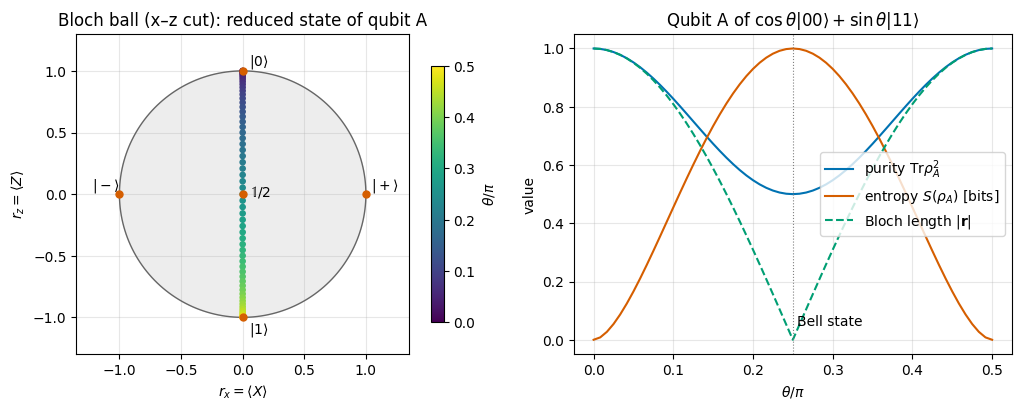

In [6]:
# ==============================================================================
# STEP 3: a qubit becomes mixed by getting entangled -- |psi> = cos(t)|00> + sin(t)|11>
# ==============================================================================
def partially_entangled_pair(theta):
    """cos(theta)|00> + sin(theta)|11> as a (2,2) tensor: product state at 0, Bell state at pi/4."""
    return jnp.cos(theta) * basis_state([0, 0]) + jnp.sin(theta) * basis_state([1, 1])


def qubit_A_diagnostics(theta):
    rho_A = rdm(partially_entangled_pair(theta), [0])          # einsum "ab,Ab->aA"
    return bloch_vector(rho_A), purity(rho_A), von_neumann_entropy(rho_A)


thetas = jnp.linspace(0.0, jnp.pi / 2, 61)
r_A, pur_A, ent_A = jax.jit(jax.vmap(qubit_A_diagnostics))(thetas)       # all 61 angles in one call

err = float(jnp.max(jnp.abs(pur_A - (1 - 0.5 * jnp.sin(2 * thetas) ** 2))))
print(f"purity versus analytic 1 - sin^2(2 theta)/2 : max error = {err:.2e}")
assert err < 10 * TOL
print(f"Bell state (theta = pi/4): rho_A =\n{np.round(np.asarray(rdm(partially_entangled_pair(jnp.pi / 4), [0])), 6)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))
# --- left: x-z cross-section of the Bloch ball ------------------------------------------------------
phi = np.linspace(0, 2 * np.pi, 200)
ax1.plot(np.cos(phi), np.sin(phi), color="0.4", lw=1)
ax1.fill(np.cos(phi), np.sin(phi), color="0.93")
sc = ax1.scatter(np.asarray(r_A[:, 0]), np.asarray(r_A[:, 2]), c=np.asarray(thetas) / np.pi, cmap="viridis", s=14, zorder=3)
fig.colorbar(sc, ax=ax1, label=r"$\theta/\pi$", shrink=0.8)
for (x, z, lab, dx, dz) in [(0, 1, r"$|0\rangle$", 0.05, 0.05), (0, -1, r"$|1\rangle$", 0.05, -0.13),
                            (1, 0, r"$|+\rangle$", 0.04, 0.04), (-1, 0, r"$|-\rangle$", -0.22, 0.04),
                            (0, 0, r"$\mathbb{1}/2$", 0.06, -0.02)]:
    ax1.plot([x], [z], "o", color=COLORS[1], ms=5, zorder=4)
    ax1.text(x + dx, z + dz, lab)
ax1.set_aspect("equal"); ax1.set_xlim(-1.35, 1.35); ax1.set_ylim(-1.3, 1.3)
ax1.set_xlabel(r"$r_x=\langle X\rangle$"); ax1.set_ylabel(r"$r_z=\langle Z\rangle$")
ax1.set_title("Bloch ball (x–z cut): reduced state of qubit A")
# --- right: purity and entropy -----------------------------------------------------------------------
ax2.plot(thetas / np.pi, pur_A, color=COLORS[0], label=r"purity $\mathrm{Tr}\rho_A^2$")
ax2.plot(thetas / np.pi, ent_A, color=COLORS[1], label=r"entropy $S(\rho_A)$ [bits]")
ax2.plot(thetas / np.pi, jnp.abs(r_A[:, 2]), color=COLORS[2], ls="--", label=r"Bloch length $|\mathbf{r}|$")
ax2.axvline(0.25, color="0.5", lw=0.8, ls=":"); ax2.text(0.255, 0.05, "Bell state")
ax2.set_xlabel(r"$\theta/\pi$"); ax2.set_ylabel("value"); ax2.legend(loc="center right")
ax2.set_title(r"Qubit A of $\cos\theta|00\rangle+\sin\theta|11\rangle$")
fig.tight_layout(); plt.show()

**Interpretation.** As $\theta$ grows from 0 the reduced state of qubit $A$ leaves the north pole $|0\rangle$ and travels
*through the interior* of the ball along the $z$-axis (left panel; colour encodes $\theta$), reaching the centre exactly at
the Bell state, and continues to the south pole $|1\rangle$ at $\theta=\pi/2$ where the pair is a product state again. The
right panel shows purity dropping from 1 to ½ while the entropy rises from 0 to 1 bit, which is, as in notebook 06, the
entanglement entropy of the pair. For a pure state of the pair, the depth of qubit $A$'s Bloch vector inside the ball
($1-|\mathbf r|$) is a direct measure of its entanglement with $B$.

> **Physics insight.** A mixed state can always be read in both ways. Given $\rho_A=\sum_i\lambda_i|i\rangle\langle i|$ one
> can *construct* a pure state $\sum_i\sqrt{\lambda_i}\,|i\rangle_A|i\rangle_B$ of a larger system whose reduced state is
> $\rho_A$ (a "purification"; it is the Schmidt decomposition of notebook 06 read backwards). Whether the randomness is
> "classical ignorance" or "entanglement with something we lost" cannot be decided by looking at $A$ alone.

## 5. The density tensor: $\rho$ as an array of rank $2N$

### 5.1 Definition

In notebook 05 the $2^N$ amplitudes became a rank-$N$ tensor $\psi[s_0,\dots,s_{N-1}]$ with one axis per qubit, and a
local operator became a contraction with one axis. We now do the same with $\rho$. A matrix element of an $N$-qubit
density operator carries a row bit string and a column bit string,

$$ \rho[s_0,\dots,s_{N-1};\,s'_0,\dots,s'_{N-1}]=\langle s_0\dots s_{N-1}|\,\rho\,|s'_0\dots s'_{N-1}\rangle, $$

so the natural container is an array of shape $(2,)\times 2N$:

* axes $0,\dots,N-1$ are the **ket axes** (row index of the matrix), axis $q$ belongs to qubit $q$;
* axes $N,\dots,2N-1$ are the **bra axes** (column index), axis $N+q$ belongs to qubit $q$.

For a pure state $\rho[s;s']=\psi[s]\,\psi^*[s']$: an **outer product**, i.e. an einsum in which nothing is summed. For
$N=2$ the string is `"ab,AB->abAB"` with operands $\psi,\psi^*$. With C-ordering, reshaping the rank-$2N$ tensor to
$(2^N,2^N)$ gives back the textbook matrix, because the first $N$ axes combine into the row index
$i=\sum_q s_q2^{N-1-q}$ and the last $N$ into the column index. The matrix and the tensor are *the same memory*, viewed
with two different shapes.

### 5.2 Trace, partial trace and expectation values in tensor form

* **Trace**: $\mathrm{Tr}\rho=\sum_s\rho[s;s]$. Give each bra axis the *same letter* as its ket axis and keep nothing:
  `"abab->"` for $N=2$.
* **Partial trace**: tie only the axes of the qubits we discard. Trace out qubit 1 of two: $\rho_0[a,A]=\sum_b\rho[a,b;A,b]$,
  `"abAb->aA"`. Trace out qubit 0: `"abaB->bB"`. (For a pure state this reproduces `rdm` of notebook 06; for a mixed
  state there is no $\psi$ to start from, and this is the only way.)
* **Local expectation value**: $\mathrm{Tr}(\rho\,O_q)$ with $O$ acting on qubit $q$. Only the reduced state of qubit $q$
  matters: $\mathrm{Tr}(\rho\,O_q)=\sum_{aA}\rho_q[a,A]\,O[A,a]=\mathrm{Tr}(\rho_q O)$.

**From formula to code.** We build a two-qubit density tensor by hand, check the three contractions against the dense
matrix, and build a genuinely mixed two-qubit state as a convex combination of two density tensors.

In [7]:
# ==============================================================================
# STEP 4: the density tensor by hand (N = 2) and its basic contractions
# ==============================================================================
key = jax.random.PRNGKey(7)
psi = haar_state(key, 2)                                       # a random pure 2-qubit state, shape (2,2)

rho_t = jnp.einsum("ab,AB->abAB", psi, jnp.conj(psi))          # density TENSOR  rho[a,b;A,B] = psi[a,b] psi*[A,B]
v = psi.reshape(-1)
rho_m = jnp.outer(v, jnp.conj(v))                              # textbook density MATRIX |psi><psi|, shape (4,4)
print("tensor shape", rho_t.shape, "| matrix shape", rho_m.shape)
print(f"reshape(tensor) == matrix : max diff = {float(jnp.max(jnp.abs(rho_t.reshape(4, 4) - rho_m))):.1e}")

# one element, spelled out: rho[s0,s1; t0,t1] sits at row 2*s0+s1, column 2*t0+t1 (C-order, qubit 0 = most significant bit)
s0, s1, t0, t1 = 1, 0, 0, 1
assert abs(rho_t[s0, s1, t0, t1] - rho_m[2 * s0 + s1, 2 * t0 + t1]) < TOL

# --- trace and partial traces --------------------------------------------------------------------------
tr = jnp.einsum("abab->", rho_t)
rho_q0 = jnp.einsum("abAb->aA", rho_t)                         # trace out qubit 1
rho_q1 = jnp.einsum("abaB->bB", rho_t)                         # trace out qubit 0
print(f"Tr rho = {float(jnp.real(tr)):.12f}")
print(f"partial traces versus rdm(psi, .) of notebook 06: {float(jnp.max(jnp.abs(rho_q0 - rdm(psi, [0])))):.1e}, "
      f"{float(jnp.max(jnp.abs(rho_q1 - rdm(psi, [1])))):.1e}")

# --- local expectation value: Tr(rho X_1) three ways -----------------------------------------------------
e_tensor = jnp.real(jnp.einsum("abaB,Bb->", rho_t, X))         # sum_{a,b,B} rho[a,b;a,B] X[B,b]
e_dense = jnp.real(jnp.trace(rho_m @ jnp.kron(I2, X)))         # textbook: Tr(rho (1 x X))
e_pure = jnp.real(jnp.vdot(psi, apply_gate(psi, X, [1])))      # <psi|X_1|psi>
print(f"<X_1>: tensor {float(e_tensor):+.10f} | dense {float(e_dense):+.10f} | pure state {float(e_pure):+.10f}")
assert abs(e_tensor - e_dense) < TOL and abs(e_tensor - e_pure) < TOL

# --- a genuinely mixed 2-qubit state: 70% Bell state + 30% |01> ---------------------------------------------
bell, k01 = bell_state("phi+"), basis_state([0, 1])
rho_mixed = 0.7 * jnp.einsum("ab,AB->abAB", bell, bell.conj()) + 0.3 * jnp.einsum("ab,AB->abAB", k01, k01.conj())
R = rho_mixed.reshape(4, 4)
print(f"\nmixture: Tr = {float(jnp.real(jnp.trace(R))):.3f}, purity = {float(purity(R)):.3f} (= 0.7^2 + 0.3^2 = 0.58), "
      f"S = {float(von_neumann_entropy(R)):.4f} bit, eigenvalues = {np.round(np.linalg.eigvalsh(np.asarray(R)), 6)}")
assert abs(float(purity(R)) - 0.58) < 1e3 * TOL

tensor shape (2, 2, 2, 2) | matrix shape (4, 4)
reshape(tensor) == matrix : max diff = 0.0e+00


Tr rho = 1.000000000000
partial traces versus rdm(psi, .) of notebook 06: 1.1e-16, 1.1e-16
<X_1>: tensor -0.0400264893 | dense -0.0400264893 | pure state -0.0400264893



mixture: Tr = 1.000, purity = 0.580 (= 0.7^2 + 0.3^2 = 0.58), S = 0.8813 bit, eigenvalues = [0.  0.  0.3 0.7]


All checks agree to machine precision. The mixture has eigenvalues $(0,0,0.3,0.7)$ because the two states we mixed
happen to be orthogonal, so its purity is $0.7^2+0.3^2$.

### 5.3 The engine versions

The general-$N$ versions build the same strings programmatically, exactly as `apply_gate` did in notebook 05. Read them
next to the by-hand strings above:

* `to_dm` is the outer product (written with `tensordot(axes=0)`, equivalent to `"ab..,AB..->ab..AB.."`);
* `dm_matrix` is the reshape $(2,)^{2N}\to(2^N,2^N)$;
* `rdm_dm` labels the ket axes `a,b,c,...` and gives a bra axis a *new* letter if the qubit is kept and the *same*
  letter as its ket axis if it is traced out. A repeated letter within one operand that is absent from the output is a trace;
* `expect_local_dm` is $\mathrm{Tr}(\rho_AO)$ with the small reduced matrix; `expect_pauli_string_dm` evaluates
  $\mathrm{Tr}(P\rho)$ for a Pauli string of any weight by applying the Paulis to the **ket axes only** (left
  multiplication, $(P\rho)[s;s']=\sum_tP[s,t]\rho[t;s']$) and then tracing.

In [8]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))

def expect_local_dm(rho, O, qubits):
    """Tr(rho O_qubits) for a density tensor, via its reduced density matrix."""
    return jnp.real(jnp.trace(rdm_dm(rho, qubits) @ jnp.asarray(O, dtype=CDTYPE)))

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string_dm(rho, ops):
    """Tr(P rho): apply P to the KET axes only, then take the full trace."""
    return jnp.real(jnp.trace(dm_matrix(apply_pauli_string(rho, ops))))


**Checkpoint.** We need mixed test states. `random_mixed_state` mixes a few Haar-random pure states with random
weights. For validation we also need the dense textbook operators of [notebook 03](../ch02_spin_systems_textbook_way/03_quantum_many_body_spin_systems.ipynb):
`embed_1q` builds $\mathbb 1\otimes\dots\otimes O\otimes\dots\otimes\mathbb 1$ with a `kron` chain, and `embed_2q` embeds
an arbitrary two-qubit matrix on *any* ordered pair of qubits by expanding it in Pauli products,
$U=\sum_{ij}c_{ij}\,\sigma_i\otimes\sigma_j$ with $c_{ij}=\tfrac14\mathrm{Tr}[(\sigma_i\otimes\sigma_j)U]$. These dense
$2^N\times2^N$ matrices exist **only to validate** the tensor code on small $N$.

In [9]:
# ==============================================================================
# VALIDATION TOOLS: random mixed states and dense (kron) embeddings -- small N only
# ==============================================================================
def random_mixed_state(key, N, rank=3):
    """Random density tensor  rho = sum_k w_k |phi_k><phi_k|  with Haar-random |phi_k> and random weights w_k."""
    kw, *ks = jax.random.split(key, rank + 1)
    w = jax.random.uniform(kw, (rank,), dtype=RDTYPE)
    w = w / jnp.sum(w)
    return sum(w[k] * to_dm(haar_state(ks[k], N)) for k in range(rank))


def kron_chain(mats):
    """Dense Kronecker product mats[0] x mats[1] x ... (qubit 0 = leftmost factor)."""
    out = jnp.ones((1, 1), dtype=CDTYPE)
    for m in mats:
        out = jnp.kron(out, jnp.asarray(m, dtype=CDTYPE))
    return out


def embed_1q(O, q, N):
    """Dense 2^N x 2^N matrix of the single-qubit operator O acting on qubit q."""
    return kron_chain([O if j == q else I2 for j in range(N)])


def embed_2q(U4, q1, q2, N):
    """Dense embedding of a 4x4 matrix on the ORDERED pair (q1, q2), q1 = left kron factor of U4.

    MATH   U4 = sum_ij c_ij (s_i x s_j),  c_ij = Tr[(s_i x s_j) U4]/4   =>   U_full = sum_ij c_ij s_i^(q1) s_j^(q2).
    Works for non-neighbouring qubits and for q1 > q2, where a plain kron chain does not.
    """
    paulis = [I2, X, Y, Z]
    out = jnp.zeros((2 ** N, 2 ** N), dtype=CDTYPE)
    for Pi in paulis:
        for Pj in paulis:
            c = jnp.trace(jnp.kron(Pi, Pj) @ U4) / 4
            out = out + c * embed_1q(Pi, q1, N) @ embed_1q(Pj, q2, N)
    return out


def check_is_state(rho, label=""):
    """Print and assert the three defining properties of a density tensor."""
    R = dm_matrix(rho)
    herm = float(jnp.max(jnp.abs(R - R.conj().T)))
    tr_err = float(jnp.abs(jnp.trace(R) - 1))
    lam_min = float(jnp.min(jnp.linalg.eigvalsh(R)))
    print(f"{label:34s} |rho-rho^dag| = {herm:.1e}   |Tr rho - 1| = {tr_err:.1e}   min eigenvalue = {lam_min:+.2e}")
    assert herm < TOL and tr_err < TOL and lam_min > -TOL


N = 4
rho = random_mixed_state(jax.random.PRNGKey(1), N)
check_is_state(rho, "random mixed state, N = 4:")
R = dm_matrix(rho)
print(f"purity = {float(purity(R)):.4f}, entropy = {float(von_neumann_entropy(R)):.4f} bit")

# rdm_dm against the dense partial trace computed by reshaping to (dA, dB, dA, dB) and tracing the B indices
ref = jnp.einsum("ibjb->ij", R.reshape(4, 4, 4, 4))                        # keep qubits (0,1), trace (2,3)
err_pt = float(jnp.max(jnp.abs(rdm_dm(rho, [0, 1]) - ref)))
# expectation values against dense matrices
err_loc = abs(float(expect_local_dm(rho, Y, [2])) - float(jnp.real(jnp.trace(R @ embed_1q(Y, 2, N)))))
P_dense = kron_chain([X, I2, Z, Y])
err_str = abs(float(expect_pauli_string_dm(rho, "XIZY")) - float(jnp.real(jnp.trace(P_dense @ R))))
print(f"rdm_dm error = {err_pt:.1e} | expect_local_dm error = {err_loc:.1e} | expect_pauli_string_dm error = {err_str:.1e}")
assert max(err_pt, err_loc, err_str) < TOL

random mixed state, N = 4:         |rho-rho^dag| = 1.4e-17   |Tr rho - 1| = 2.0e-18   min eigenvalue = -6.39e-17
purity = 0.4354, entropy = 1.3357 bit


rdm_dm error = 5.6e-17 | expect_local_dm error = 6.9e-18 | expect_pauli_string_dm error = 0.0e+00


> **Numerical practice.** The density tensor holds $4^N$ complex numbers, the *square* of the state vector's $2^N$. With
> `complex128` (16 bytes) one copy takes $16\cdot4^N$ bytes: 1 MB at $N=8$, 17 MB at $N=10$, 268 MB at $N=12$, 1.1 GB at
> $N=13$, 4.3 GB at $N=14$. A computation holds several copies at once (input, output, einsum intermediates), so on a
> laptop with 16 GB of memory everything in §5–§10 ends at $N\approx13$–$14$. This is the ceiling quoted in the rest of
> the notebook. §11 removes it at the price of statistical noise.

## 6. Unitary evolution of a density tensor

### 6.1 Derivation

If every member of the ensemble evolves as $|\psi_k\rangle\to U|\psi_k\rangle$, then by Eq. (1)

$$ \rho\;\to\;\sum_kp_k\,U|\psi_k\rangle\langle\psi_k|U^\dagger=U\rho\,U^\dagger . $$

In components, using $(U^\dagger)_{lj}=U^*_{jl}$:

$$ \rho'_{ij}=\sum_{k,l}U_{ik}\,\rho_{kl}\,(U^\dagger)_{lj}=\sum_{k,l}U_{ik}\;U^*_{jl}\;\rho_{kl}.\qquad\text{(Eq. 2)} $$

Read Eq. (2) as a recipe: **the row (ket) index of $\rho$ is contracted with $U$, the column (bra) index with the
complex conjugate $U^*$**, both in the pattern "new index first, old index second", which is exactly the pattern of
`apply_gate`. No transpose and no dagger are needed; the dagger has been absorbed into the index placement.

For a gate on qubit $q$ of an $N$-qubit density tensor only the ket axis $q$ and the bra axis $N+q$ are touched:

$$ \rho'[..,A,..;..,B,..]=\sum_{a,c}U[A,a]\;U^*[B,c]\;\rho[..,a,..;..,c,..]. $$

### 6.2 Einsum strings by hand

Label the axes of a two-qubit density tensor `abcd` = (ket 0, ket 1, bra 0, bra 1). Operands are always $(U,U^*,\rho)$.

| case | einsum string | touched axes |
|---|---|---|
| $N=2$, gate on qubit 0 | `"Aa,Bc,abcd->AbBd"` | ket 0 (`a`→`A`), bra 0 (`c`→`B`) |
| $N=2$, gate on qubit 1 | `"Ab,Bd,abcd->aAcB"` | ket 1 (`b`→`A`), bra 1 (`d`→`B`) |
| $N=3$, two-qubit gate on qubits (0,2); axes `abc`,`def` | `"ABac,CDdf,abcdef->AbBCeD"` | kets 0,2 (`a`,`c`→`A`,`B`), bras 0,2 (`d`,`f`→`C`,`D`) |

In the last line the $4\times4$ gate has been reshaped to $U[A,B,a,c]$ (outputs first, inputs second, first qubit =
most significant bit, as in notebook 05), and the two qubits are *not* neighbours, which costs nothing.

In [10]:
# ==============================================================================
# STEP 5: U rho U^dagger by hand -- einsum strings for N = 2 and N = 3, checked against kron
# ==============================================================================
k1, k2, k3, k4 = jax.random.split(jax.random.PRNGKey(11), 4)
U = haar_unitary(k1, 2)                                        # a random single-qubit unitary

# ---- N = 2 ---------------------------------------------------------------------------------------------
rho2 = random_mixed_state(k2, 2)
R2 = dm_matrix(rho2)
out_q0 = jnp.einsum("Aa,Bc,abcd->AbBd", U, jnp.conj(U), rho2)
out_q1 = jnp.einsum("Ab,Bd,abcd->aAcB", U, jnp.conj(U), rho2)
ref_q0 = jnp.kron(U, I2) @ R2 @ jnp.kron(U, I2).conj().T       # textbook (U x 1) rho (U x 1)^dagger
ref_q1 = jnp.kron(I2, U) @ R2 @ jnp.kron(I2, U).conj().T
e0 = float(jnp.max(jnp.abs(out_q0.reshape(4, 4) - ref_q0)))
e1 = float(jnp.max(jnp.abs(out_q1.reshape(4, 4) - ref_q1)))
print(f"N=2: gate on qubit 0: error = {e0:.1e} | gate on qubit 1: error = {e1:.1e}")
assert max(e0, e1) < TOL

# ---- N = 3, CNOT with control 0 and target 2 (non-neighbours) ----------------------------------------------
rho3 = random_mixed_state(k3, 3)
R3 = dm_matrix(rho3)
C4 = CNOT.reshape(2, 2, 2, 2)                                  # C4[A,B,a,c]: outputs (A,B), inputs (a,c)
out_cnot = jnp.einsum("ABac,CDdf,abcdef->AbBCeD", C4, jnp.conj(C4), rho3)
CNOT_02 = kron_chain([P0, I2, I2]) + kron_chain([P1, I2, X])   # |0><0| x 1 x 1 + |1><1| x 1 x X
e2 = float(jnp.max(jnp.abs(out_cnot.reshape(8, 8) - CNOT_02 @ R3 @ CNOT_02.conj().T)))
print(f"N=3: CNOT(0 -> 2)      : error = {e2:.1e}")
assert e2 < TOL

N=2: gate on qubit 0: error = 0.0e+00 | gate on qubit 1: error = 0.0e+00


N=3: CNOT(0 -> 2)      : error = 0.0e+00


The hand-written strings reproduce the dense result to machine precision.

### 6.3 The engine version: two calls of `apply_gate`

Look at the strings again: the part `"Aa,...abcd->Ab.d"` is *precisely* what `apply_gate(rho, U, [0])` generates when
it is handed a rank-4 tensor, and the part with $U^*$ is `apply_gate(rho, U.conj(), [N+0])`. The engine therefore needs
**no new einsum code** for density tensors:

> A density tensor of $N$ qubits behaves like a state vector of $2N$ qubits, on which $U\otimes U^*$ acts: $U$ on
> "qubit" $q$ and $U^*$ on "qubit" $N+q$. (In the literature this is called *vectorisation*, $|\rho\rangle\!\rangle$.)

The cost is two einsums over $4^N$ entries: $O(2^k4^N)$ for a $k$-qubit gate, against $O(8^N)$ for the dense
triple matrix product.

In [11]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes


In [12]:
# ==============================================================================
# CHECKPOINT: apply_gate_dm against dense U rho U^dagger -- all single-qubit targets, several ordered pairs
# ==============================================================================
N = 3
rho = random_mixed_state(jax.random.PRNGKey(2), N)
R = dm_matrix(rho)
keys = jax.random.split(jax.random.PRNGKey(3), 8)

worst = 0.0
for q in range(N):                                             # single-qubit gates on every qubit
    U1 = haar_unitary(keys[q], 2)
    Uf = embed_1q(U1, q, N)
    worst = max(worst, float(jnp.max(jnp.abs(dm_matrix(apply_gate_dm(rho, U1, [q])) - Uf @ R @ Uf.conj().T))))
for i, (q1, q2) in enumerate([(0, 1), (1, 2), (0, 2), (2, 0)]):  # two-qubit gates, incl. non-neighbours and reversed order
    U2 = haar_unitary(keys[3 + i], 4)
    Uf = embed_2q(U2, q1, q2, N)
    worst = max(worst, float(jnp.max(jnp.abs(dm_matrix(apply_gate_dm(rho, U2, [q1, q2])) - Uf @ R @ Uf.conj().T))))
print(f"apply_gate_dm versus dense, 7 gates: worst error = {worst:.1e}")
assert worst < TOL

# a unitary cannot change the eigenvalues of rho: purity and entropy are conserved
rho_U = apply_gate_dm(apply_gate_dm(rho, H, [0]), CNOT, [0, 2])
dp = abs(float(purity(dm_matrix(rho_U))) - float(purity(R)))
dS = abs(float(von_neumann_entropy(dm_matrix(rho_U))) - float(von_neumann_entropy(R)))
print(f"after H and CNOT: |change of purity| = {dp:.1e}, |change of entropy| = {dS:.1e}")
assert dp < TOL and dS < 1e3 * TOL

apply_gate_dm versus dense, 7 gates: worst error = 6.2e-17
after H and CNOT: |change of purity| = 1.1e-16, |change of entropy| = 3.8e-15


> **Physics insight.** $U\rho U^\dagger$ has the same eigenvalues as $\rho$. *Unitary dynamics can never make a state more
> mixed or more pure.* To describe noise, relaxation or measurement we need a larger class of maps.

## 7. Quantum channels and the Kraus representation

### 7.1 Noise as a random unitary

The simplest noise model: with probability $p$ an unwanted $X$ (a "bit flip") hits the qubit, otherwise nothing
happens. Applying the ensemble rule Eq. (1) to the two alternatives,

$$ \rho\to\mathcal E(\rho)=(1-p)\,\rho+p\,X\rho X=\sum_{m=0}^{1}K_m\rho K_m^\dagger,\qquad K_0=\sqrt{1-p}\,\mathbb 1,\;\;K_1=\sqrt p\,X . $$

The map is *linear in $\rho$* but not of the form $U\rho U^\dagger$. It mixes: the eigenvalues of $\rho$ change.

### 7.2 Noise as entanglement with an environment (derivation of the Kraus form)

The general case follows from §4. Let the system $S$ start in $\rho$ and the environment $E$ in a fixed state
$|0\rangle_E$. They interact through a joint unitary $U$, after which we ignore (trace out) the environment. Evaluating
the partial trace in an orthonormal basis $\{|m\rangle_E\}$:

$$ \mathcal E(\rho)=\mathrm{Tr}_E\Big[U\big(\rho\otimes|0\rangle\langle0|\big)U^\dagger\Big]
   =\sum_m\langle m|_E\,U\,|0\rangle_E\;\rho\;\langle0|_E\,U^\dagger\,|m\rangle_E=\sum_mK_m\,\rho\,K_m^\dagger ,\qquad\text{(Eq. 3)} $$

$$ K_m=\langle m|_E\,U\,|0\rangle_E\quad\text{(an operator on $S$: a "slice" of $U$ with the environment indices fixed).} $$

The **Kraus operators** $K_m$ are in general neither unitary nor Hermitian, but they satisfy a **completeness relation**
inherited from $U^\dagger U=\mathbb 1$:

$$ \sum_mK_m^\dagger K_m=\sum_m\langle0|U^\dagger|m\rangle\langle m|U|0\rangle=\langle0|U^\dagger U|0\rangle=\mathbb 1_S .\qquad\text{(Eq. 4)} $$

Completeness is what makes the map **trace preserving**:
$\mathrm{Tr}\,\mathcal E(\rho)=\mathrm{Tr}\big(\sum_mK_m^\dagger K_m\,\rho\big)=\mathrm{Tr}\rho$ (cyclicity of the trace). Each term
$K\rho K^\dagger$ is positive if $\rho$ is, so $\mathcal E(\rho)$ is again a valid state.

**Why "completely" positive.** A linear map that sends states of the system to states of the system is called
*positive*. Physical maps must satisfy a stronger condition. The system may be one half of an entangled pair whose other half $R$ is
a spectator that the channel does not touch; the physical map is then $\mathcal E\otimes\mathrm{id}_R$, and *it* must
send joint states to joint states, for a spectator of **any** dimension. A map with that stronger property is
**completely positive**. The two notions really differ: the transposition $\rho\to\rho^{\mathrm T}$ is positive
(transposing does not change the eigenvalues) but not completely positive, because transposing only the first qubit of
the Bell state $(|00\rangle+|11\rangle)/\sqrt2$ gives a matrix with eigenvalues
$(\tfrac12,\tfrac12,\tfrac12,-\tfrac12)$, one of which would be a negative probability. §10.1 turns exactly this
failure into an entanglement detector. The Kraus form (3) is manifestly completely positive, because
$\sum_m(K_m\otimes\mathbb 1_R)\,\Omega\,(K_m\otimes\mathbb 1_R)^\dagger$ is a sum of positive operators for every joint
state $\Omega$. Maps that are completely positive and trace preserving are called **quantum channels** (CPTP maps).

We quote without proof the converse (Kraus' theorem, Kraus 1983; see Nielsen & Chuang §8.2): *every* CPTP map on a $d$-dimensional
system can be written in the form (3) with operators obeying (4), and at most $d^2$ Kraus operators are ever needed —
equivalently, an environment of dimension $d^2$ always suffices in the construction above. That construction
("unitary on system + environment, then discard the environment") is the **Stinespring dilation** of the channel (Stinespring 1955);
Eq. (3) is that dilation read in the other direction, from the joint unitary to the Kraus operators.

The index $m$ has a physical meaning: it labels **what the environment could have recorded** (photon emitted / not
emitted, error happened / did not happen). This reading is the basis of the trajectory method of §11.

**From formula to code.** We take a concrete system–environment interaction, a rotation by an angle $\theta$ in the
subspace $\{|1\rangle_S|0\rangle_E,\;|0\rangle_S|1\rangle_E\}$ that coherently hands the excitation of the system over to the
environment (an atom emitting a photon). Reshaping the $4\times4$ matrix to $U[s,e,s',e']$ makes Eq. (3) a *slicing*
operation: $K_m[s,s']=U[s,m,s',0]$. We then verify that "evolve jointly, then trace out $E$" equals the Kraus sum.

In [13]:
# ==============================================================================
# STEP 6: Kraus operators as slices of a system+environment unitary
# ==============================================================================
theta = 0.6
c, s = np.cos(theta), np.sin(theta)
# basis |s e> = |00>, |01>, |10>, |11>  (system = first qubit, environment = second qubit)
U_SE = jnp.array([[1, 0, 0, 0],
                  [0, c, s, 0],            # |1>_S|0>_E -> cos(theta)|10> + sin(theta)|01> : the excitation leaks out
                  [0, -s, c, 0],
                  [0, 0, 0, 1]], dtype=CDTYPE)
assert float(jnp.max(jnp.abs(U_SE.conj().T @ U_SE - jnp.eye(4)))) < TOL

U_t = U_SE.reshape(2, 2, 2, 2)                                 # U[s, e, s', e']
K_env = jnp.stack([U_t[:, m, :, 0] for m in (0, 1)])           # K_m = <m|_E U |0>_E   (Eq. 3)
print("K_0 =\n", np.round(np.asarray(K_env[0]).real, 4), "\nK_1 =\n", np.round(np.asarray(K_env[1]).real, 4))

completeness = jnp.einsum("mba,mbc->ac", jnp.conj(K_env), K_env)   # sum_m K_m^dagger K_m   (Eq. 4)
print(f"completeness: max |sum K^dag K - 1| = {float(jnp.max(jnp.abs(completeness - I2))):.1e}")

# --- route 1: joint unitary evolution of rho_S x |0><0|_E, then partial trace over E ---------------------------
rho_S = dm_matrix(random_mixed_state(jax.random.PRNGKey(5), 1))
rho_SE = jnp.einsum("sS,eE->seSE", rho_S, P0)                  # density tensor of system (qubit 0) + environment (qubit 1)
route1 = rdm_dm(apply_gate_dm(rho_SE, U_SE, [0, 1]), [0])
# --- route 2: Kraus sum on the system alone ---------------------------------------------------------------------
route2 = sum(K @ rho_S @ K.conj().T for K in K_env)
err = float(jnp.max(jnp.abs(route1 - route2)))
print(f"Tr_E[U (rho x |0><0|) U^dag]  versus  sum_m K_m rho K_m^dag : max diff = {err:.1e}")
assert err < TOL

K_0 =
 [[1.     0.    ]
 [0.     0.8253]] 
K_1 =
 [[0.     0.5646]
 [0.     0.    ]]
completeness: max |sum K^dag K - 1| = 0.0e+00


Tr_E[U (rho x |0><0|) U^dag]  versus  sum_m K_m rho K_m^dag : max diff = 0.0e+00


The slices are $K_0=\mathrm{diag}(1,\cos\theta)$ and $K_1=\sin\theta\,|0\rangle\langle1|$. With $\gamma=\sin^2\theta$ these
are the Kraus operators of the **amplitude-damping channel** that we meet again in §9: "no photon was emitted" and
"a photon was emitted". Both routes agree to machine precision. The environment has been eliminated, and only a small
stack of $2\times2$ matrices remains of it.

## 8. A Kraus channel as one einsum

### 8.1 Derivation and by-hand strings

Stack the Kraus operators into one array $K[m,A,a]$ of shape $(M,2,2)$. Writing Eq. (3) in components exactly as we
did for Eq. (2),

$$ \rho'[A;B]=\sum_{m}\sum_{a,c}K[m,A,a]\;K^*[m,B,c]\;\rho[a;c] . $$

The only difference from the unitary case is the extra letter $m$, shared by $K$ and $K^*$ and **absent from the
output**: by the einsum rules it is summed. All Kraus branches are therefore accumulated *inside one einsum call*;
there is no Python loop over $m$.

| case (operands $K,K^*,\rho$) | einsum string |
|---|---|
| $N=1$ | `"mAa,mBc,ac->AB"` |
| $N=2$, channel on qubit 0, axes `abcd` = (ket 0, ket 1, bra 0, bra 1) | `"mAa,mBc,abcd->AbBd"` |
| $N=2$, channel on qubit 1 | `"mAb,mBd,abcd->aAcB"` |

Compare with the table of §6.2: the same strings with an `m` in front of both operator labels.

In [14]:
# ==============================================================================
# STEP 7: sum_m K_m rho K_m^dagger by hand -- the Kraus index m is summed INSIDE the einsum
# ==============================================================================
K = K_env                                                      # the two Kraus operators found above, shape (2,2,2)

# ---- N = 1 -----------------------------------------------------------------------------------------------
out1 = jnp.einsum("mAa,mBc,ac->AB", K, jnp.conj(K), rho_S)
e_a = float(jnp.max(jnp.abs(out1 - route2)))

# ---- N = 2, channel on qubit 0 and on qubit 1 ------------------------------------------------------------
out_q0 = jnp.einsum("mAa,mBc,abcd->AbBd", K, jnp.conj(K), rho2)
out_q1 = jnp.einsum("mAb,mBd,abcd->aAcB", K, jnp.conj(K), rho2)
ref_q0 = sum(jnp.kron(Km, I2) @ R2 @ jnp.kron(Km, I2).conj().T for Km in K)   # textbook: loop over m, dense matrices
ref_q1 = sum(jnp.kron(I2, Km) @ R2 @ jnp.kron(I2, Km).conj().T for Km in K)
e_b = float(jnp.max(jnp.abs(out_q0.reshape(4, 4) - ref_q0)))
e_c = float(jnp.max(jnp.abs(out_q1.reshape(4, 4) - ref_q1)))
print(f"N=1: error = {e_a:.1e} | N=2, qubit 0: error = {e_b:.1e} | N=2, qubit 1: error = {e_c:.1e}")
assert max(e_a, e_b, e_c) < TOL

N=1: error = 0.0e+00 | N=2, qubit 0: error = 5.6e-17 | N=2, qubit 1: error = 3.9e-18


### 8.2 The engine function `apply_kraus_dm`

`apply_kraus_dm(rho, kraus, qubits)` generates these strings for any $N$ and any $k$-qubit channel:

1. reshape the stack $(M,2^k,2^k)\to(M,\underbrace{2,\dots,2}_{k\text{ outputs}},\underbrace{2,\dots,2}_{k\text{ inputs}})$;
2. label the $2N$ axes of $\rho$ with the first $2N$ letters (`inp`);
3. take $k$ fresh letters for the new ket indices (`new_k`), $k$ more for the new bra indices (`new_b`) and one more for the Kraus index `m`;
4. the output labels are those of $\rho$ with the letters of axes $q$ and $N+q$ replaced by the fresh ones;
5. the string is `"m new_k ket_old , m new_b bra_old , inp -> out"` with operands $(K,K^*,\rho)$.

The small helper below repeats steps 2–5 just to *print* the string, so that you can compare with the hand-written ones.

In [15]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


In [16]:
# ==============================================================================
# The strings that apply_kraus_dm generates (same logic as in the engine, printing only)
# ==============================================================================
def kraus_einsum_string(N, qubits):
    """Return the einsum string used by `apply_kraus_dm` for an N-qubit density tensor and target `qubits`."""
    k, n = len(qubits), 2 * N
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old, bra_old = "".join(inp[q] for q in qubits), "".join(inp[N + q] for q in qubits)
    return f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"


for N_, qs in [(1, [0]), (2, [0]), (2, [1]), (3, [0, 2]), (6, [4])]:
    print(f"N = {N_}, qubits = {str(qs):7s}:  {kraus_einsum_string(N_, qs)}")

N = 1, qubits = [0]    :  eca,edb,ab->cd
N = 2, qubits = [0]    :  gea,gfc,abcd->ebfd
N = 2, qubits = [1]    :  geb,gfd,abcd->aecf
N = 3, qubits = [0, 2] :  kghac,kijdf,abcdef->gbhiej
N = 6, qubits = [4]    :  ome,onk,abcdefghijkl->abcdmfghijnl


For $N=2$, qubit 0 the engine prints `gea,gfc,abcd->ebfd`: our hand-written `"mAa,mBc,abcd->AbBd"` with the letters
`m,A,B` renamed to `g,e,f`. Letters are dummy names; only the *pattern* matters.

**Checkpoint.** A strong test uses Kraus operators without any special structure. Following Eq. (3) we cut them out of a
Haar-random unitary on system + a four-dimensional environment, which yields four random $2\times2$ (or $4\times4$) Kraus
operators that satisfy completeness by construction. We test every target qubit, a two-qubit channel on
non-neighbouring qubits in reversed order, and verify that the output is a valid state.

In [17]:
# ==============================================================================
# CHECKPOINT: apply_kraus_dm against the dense Kraus sum, random channels
# ==============================================================================
def random_kraus(key, d_sys, d_env=4):
    """Random channel on a d_sys-dimensional system: K_m = <m|_E V |0>_E with V Haar-random on system x environment."""
    V = haar_unitary(key, d_sys * d_env).reshape(d_sys, d_env, d_sys, d_env)
    return jnp.stack([V[:, m, :, 0] for m in range(d_env)])


def completeness_error(kraus):
    """max | sum_m K_m^dagger K_m - 1 |   (Eq. 4)."""
    Kc = jnp.asarray(kraus, dtype=CDTYPE)
    return float(jnp.max(jnp.abs(jnp.einsum("mba,mbc->ac", jnp.conj(Kc), Kc) - jnp.eye(Kc.shape[-1]))))


N = 3
rho = random_mixed_state(jax.random.PRNGKey(21), N)
R = dm_matrix(rho)
keys = jax.random.split(jax.random.PRNGKey(22), 4)

worst = 0.0
for q in range(N):
    Kq = random_kraus(keys[q], 2)
    ref = sum(embed_1q(Km, q, N) @ R @ embed_1q(Km, q, N).conj().T for Km in Kq)
    worst = max(worst, float(jnp.max(jnp.abs(dm_matrix(apply_kraus_dm(rho, Kq, [q])) - ref))))
K2 = random_kraus(keys[3], 4)                                  # a genuine two-qubit channel (4 Kraus operators, 4x4)
ref = sum(embed_2q(Km, 2, 0, N) @ R @ embed_2q(Km, 2, 0, N).conj().T for Km in K2)
out = apply_kraus_dm(rho, K2, [2, 0])
worst = max(worst, float(jnp.max(jnp.abs(dm_matrix(out) - ref))))
print(f"completeness errors: 1-qubit {completeness_error(Kq):.1e}, 2-qubit {completeness_error(K2):.1e}")
print(f"apply_kraus_dm versus dense Kraus sum (3 single-qubit + 1 two-qubit channel): worst error = {worst:.1e}")
assert worst < TOL
check_is_state(out, "output of the two-qubit channel:")
print(f"purity before {float(purity(R)):.4f} -> after {float(purity(dm_matrix(out))):.4f}")

completeness errors: 1-qubit 2.2e-16, 2-qubit 4.4e-16
apply_kraus_dm versus dense Kraus sum (3 single-qubit + 1 two-qubit channel): worst error = 5.7e-17
output of the two-qubit channel:   |rho-rho^dag| = 1.6e-17   |Tr rho - 1| = 1.9e-18   min eigenvalue = +5.75e-03
purity before 0.3936 -> after 0.2187


The single einsum matches the dense loop over $m$ to machine precision; the output is Hermitian, has unit trace and no
negative eigenvalue. Unlike a unitary, a channel changes the purity.

## 9. The channel zoo

### 9.1 Five standard single-qubit channels

| channel | Kraus operators | action on $\rho$ | physical origin |
|---|---|---|---|
| **bit flip** | $\sqrt{1-p}\,\mathbb 1,\;\sqrt p\,X$ | $(1-p)\rho+pX\rho X$ | random $X$ errors (classical bit errors in a memory) |
| **phase flip = dephasing** | $\sqrt{1-p}\,\mathbb 1,\;\sqrt p\,Z$ | $(1-p)\rho+pZ\rho Z$; $\;\rho_{01}\to(1-2p)\rho_{01}$ | fluctuating energy splitting (magnetic-field noise); "$T_\phi$", part of $T_2$ |
| **depolarising** | $\sqrt{1-p}\,\mathbb 1,\;\sqrt{p/3}\,X,\;\sqrt{p/3}\,Y,\;\sqrt{p/3}\,Z$ | $(1-p)\rho+\tfrac p3(X\rho X+Y\rho Y+Z\rho Z)$ | unbiased noise; the standard model of gate errors |
| **amplitude damping** | $\begin{pmatrix}1&0\\0&\sqrt{1-\gamma}\end{pmatrix},\;\begin{pmatrix}0&\sqrt\gamma\\0&0\end{pmatrix}$ | $\rho_{11}\to(1-\gamma)\rho_{11}$, $\rho_{01}\to\sqrt{1-\gamma}\rho_{01}$ | spontaneous emission, energy relaxation; "$T_1$" |
| **phase damping** | $\begin{pmatrix}1&0\\0&\sqrt{1-\lambda}\end{pmatrix},\;\begin{pmatrix}0&0\\0&\sqrt\lambda\end{pmatrix}$ | $\rho_{01}\to\sqrt{1-\lambda}\,\rho_{01}$, populations fixed | elastic scattering: the environment learns *whether* the qubit is in $\vert1\rangle$ |

In the first three, "with probability $p$ an error happens" is exactly true, and the Kraus operators are rescaled
unitaries. The last two are of the system–environment type of §7.2 and their Kraus operators are not proportional to
unitaries. If noise acts continuously at a rate, a time step $\Delta t$ corresponds to
$\gamma=1-e^{-\Delta t/T_1}$ for amplitude damping and $1-2p=e^{-\Delta t/T_\phi}$ for pure dephasing
(the continuous-time theory is the subject of [notebook 16](../ch06_open_quantum_systems/16_lindblad_master_equation.ipynb), Chapter 6).

The engine provides the first four (`kraus_phase_flip` is an alias of `kraus_dephasing`); we add phase damping here in
the same style.

In [18]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)

# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_bit_flip(p):
    """Bit-flip channel  rho -> (1-p) rho + p X rho X."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * X])

def kraus_phase_flip(p):
    """Phase-flip channel (identical to dephasing)."""
    return kraus_dephasing(p)

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) |0><1| = sqrt(g) sigma^+, engine SP)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])


In [19]:
# ==============================================================================
# STEP 8: one more channel in engine style, the zoo as a dictionary, completeness of every channel
# ==============================================================================
def kraus_phase_damping(lam):
    """Phase-damping channel: coherences rho_01 -> sqrt(1-lam) rho_01, populations untouched.
        K0 = [[1,0],[0,sqrt(1-lam)]]    ('the environment did not notice the qubit')
        K1 = [[0,0],[0,sqrt(lam)]]      ('the environment scattered off |1>' = sqrt(lam) |1><1|)
    Same channel as `kraus_dephasing(p)` with 1-2p = sqrt(1-lam), in a DIFFERENT Kraus representation."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - lam)]], dtype=CDTYPE)
    K1 = jnp.array([[0, 0], [0, jnp.sqrt(lam)]], dtype=CDTYPE)
    return jnp.stack([K0, K1])


CHANNELS = {                                                   # name -> function(strength) returning the Kraus stack
    "bit flip": kraus_bit_flip,
    "dephasing": kraus_dephasing,
    "depolarising": kraus_depolarizing,
    "amplitude damping": kraus_amplitude_damping,
    "phase damping": kraus_phase_damping,
}

for name, fn in CHANNELS.items():
    Kc = fn(0.3)
    err = completeness_error(Kc)
    print(f"{name:18s}: {Kc.shape[0]} Kraus operators, max |sum K^dag K - 1| = {err:.1e}")
    assert err < TOL

# the environment model of section 7 IS amplitude damping with gamma = sin^2(theta)
err = float(jnp.max(jnp.abs(K_env - kraus_amplitude_damping(np.sin(theta) ** 2))))
print(f"\nKraus slices of section 7 versus kraus_amplitude_damping(sin^2 theta): max diff = {err:.1e}")
assert err < TOL

bit flip          : 2 Kraus operators, max |sum K^dag K - 1| = 0.0e+00
dephasing         : 2 Kraus operators, max |sum K^dag K - 1| = 0.0e+00
depolarising      : 4 Kraus operators, max |sum K^dag K - 1| = 0.0e+00
amplitude damping : 2 Kraus operators, max |sum K^dag K - 1| = 0.0e+00
phase damping     : 2 Kraus operators, max |sum K^dag K - 1| = 0.0e+00

Kraus slices of section 7 versus kraus_amplitude_damping(sin^2 theta): max diff = 1.1e-16


### 9.2 First sanity checks on simple states

Before using a channel in a many-body simulation we confirm the textbook facts of the table on states where the answer
is known by heart. Each line below is an `assert` with a printed error.

In [20]:
# ==============================================================================
# CHECKPOINT: textbook properties of each channel on |0>, |1>, |+>
# ==============================================================================
rho_0, rho_1, rho_p = (to_dm(product_state(c)) for c in "01+")        # single-qubit density tensors (2,2)

def report(text, err):
    print(f"  {text:74s} error = {err:.1e}")
    assert err < TOL

print("dephasing, p = 0.25 on |+>:")
out = apply_kraus_dm(rho_p, kraus_dephasing(0.25), [0])
report("populations unchanged (1/2, 1/2)", float(jnp.max(jnp.abs(jnp.diag(out) - 0.5))))
report("coherence rho_01 scaled by (1 - 2p) = 0.5", float(jnp.abs(out[0, 1] - 0.5 * 0.5)))
out = apply_kraus_dm(rho_p, kraus_dephasing(0.5), [0])
report("p = 1/2 kills the coherence completely: rho = 1/2", float(jnp.max(jnp.abs(out - I2 / 2))))

print("amplitude damping:")
report("|1> with gamma = 0.5  ->  diag(0.5, 0.5)",
       float(jnp.max(jnp.abs(apply_kraus_dm(rho_1, kraus_amplitude_damping(0.5), [0]) - I2 / 2))))
report("|0> is a fixed point (gamma = 0.9)",
       float(jnp.max(jnp.abs(apply_kraus_dm(rho_0, kraus_amplitude_damping(0.9), [0]) - rho_0))))

print("bit flip on |0>:")
report("p = 0.5  ->  (|0><0| + |1><1|)/2", float(jnp.max(jnp.abs(apply_kraus_dm(rho_0, kraus_bit_flip(0.5), [0]) - I2 / 2))))
report("p = 1    ->  |1><1|", float(jnp.max(jnp.abs(apply_kraus_dm(rho_0, kraus_bit_flip(1.0), [0]) - rho_1))))

print("depolarising on |0>:")
report("p = 3/4  ->  maximally mixed state 1/2",
       float(jnp.max(jnp.abs(apply_kraus_dm(rho_0, kraus_depolarizing(0.75), [0]) - I2 / 2))))

print("phase damping on |+>, lambda = 0.36:")
out = apply_kraus_dm(rho_p, kraus_phase_damping(0.36), [0])
report("coherence scaled by sqrt(1 - lambda) = 0.8, populations unchanged",
       float(jnp.abs(out[0, 1] - 0.4) + jnp.max(jnp.abs(jnp.diag(out) - 0.5))))

dephasing, p = 0.25 on |+>:


  populations unchanged (1/2, 1/2)                                           error = 2.2e-16
  coherence rho_01 scaled by (1 - 2p) = 0.5                                  error = 1.4e-16
  p = 1/2 kills the coherence completely: rho = 1/2                          error = 0.0e+00
amplitude damping:
  |1> with gamma = 0.5  ->  diag(0.5, 0.5)                                   error = 1.1e-16
  |0> is a fixed point (gamma = 0.9)                                         error = 0.0e+00
bit flip on |0>:
  p = 0.5  ->  (|0><0| + |1><1|)/2                                           error = 1.1e-16
  p = 1    ->  |1><1|                                                        error = 0.0e+00
depolarising on |0>:


  p = 3/4  ->  maximally mixed state 1/2                                     error = 0.0e+00
phase damping on |+>, lambda = 0.36:
  coherence scaled by sqrt(1 - lambda) = 0.8, populations unchanged          error = 2.2e-16


> **Common pitfall.** Parametrisations differ between books and codes. With our depolarising convention
> $\rho\to(1-p)\rho+\tfrac p3(\dots)$ the state is *completely* depolarised already at $p=3/4$ (checked above); some
> authors write $\rho\to(1-p')\rho+p'\,\mathbb 1/2$ instead, with $p'=4p/3$. Likewise, dephasing is complete at $p=1/2$, and at
> $p=1$ the channel is just the unitary $Z$. Always check the convention with a one-line test like the ones above.

### 9.3 Action on the Bloch vector

A single-qubit channel is linear and trace preserving, so it acts on the Bloch vector as an **affine map**
$\mathbf r\to M\mathbf r+\mathbf c$ with a real $3\times3$ matrix $M$ and a shift $\mathbf c$.

**Pauli channels** $\rho\to\sum_kp_k\sigma_k\rho\sigma_k$ (with $\sigma_0=\mathbb 1$). Insert
$\rho=\tfrac12(\mathbb 1+\sum_jr_j\sigma_j)$ and use $\sigma_k\sigma_j\sigma_k=+\sigma_j$ if $k=j$ or $k=0$, and $-\sigma_j$
otherwise (different Pauli matrices anticommute):

$$ r_j\;\to\;\Big(p_0+p_j-\sum_{k\ne0,j}p_k\Big)\,r_j . $$

* bit flip ($p_x=p$): $(r_x,r_y,r_z)\to(r_x,\,(1-2p)r_y,\,(1-2p)r_z)$. The sphere is squeezed towards the $x$-axis.
* phase flip/dephasing ($p_z=p$): $(r_x,r_y,r_z)\to((1-2p)r_x,\,(1-2p)r_y,\,r_z)$. Squeezed towards the $z$-axis:
  coherences die, populations survive.
* depolarising ($p_x=p_y=p_z=p/3$): every component is multiplied by $1-p+\tfrac p3-\tfrac{2p}3=1-\tfrac{4p}3$. A uniform
  shrinking towards the centre.

**Amplitude damping.** Directly from the matrices: $K_0\rho K_0^\dagger$ multiplies $\rho_{01}$ by $\sqrt{1-\gamma}$ and
$\rho_{11}$ by $1-\gamma$, while $K_1\rho K_1^\dagger=\gamma\rho_{11}|0\rangle\langle0|$ moves the lost population to $|0\rangle$. With
$r_z=\rho_{00}-\rho_{11}$ and $\rho_{11}=(1-r_z)/2$:

$$ (r_x,r_y,r_z)\to\big(\sqrt{1-\gamma}\,r_x,\;\sqrt{1-\gamma}\,r_y,\;\gamma+(1-\gamma)\,r_z\big). $$

This map has a **shift**: the ball shrinks *and moves towards the north pole* $|0\rangle$, the ground state. Amplitude
damping can therefore *increase* purity. It is the only channel of our zoo that is not *unital*
($\mathcal E(\mathbb 1)\neq\mathbb 1$).

**From formula to code.** $M$ and $\mathbf c$ can be extracted from *any* Kraus stack by feeding the channel with the
operators $\mathbb 1$ and $\sigma_b$ (it is linear, so it does not mind that these are not states):
$c_a=\tfrac12\mathrm{Tr}[\sigma_a\,\mathcal E(\mathbb 1)]$ and $M_{ab}=\tfrac12\mathrm{Tr}[\sigma_a\,\mathcal E(\sigma_b)]$.

In [21]:
# ==============================================================================
# STEP 9: the affine Bloch-ball map  r -> M r + c  of a single-qubit channel
# ==============================================================================
def bloch_map(kraus):
    """Affine action of a single-qubit channel on the Bloch vector:  r -> M r + c.

    MATH   M_ab = Tr[ s_a E(s_b) ]/2 ,   c_a = Tr[ s_a E(1) ]/2 ,   E(A) = sum_m K_m A K_m^dagger.
    IMPLEMENTATION  the channel is applied with `apply_kraus_dm` to the 2x2 arrays 1, X, Y, Z (linearity).
    """
    paulis = (X, Y, Z)
    E = lambda A: apply_kraus_dm(A, kraus, [0])
    M = jnp.real(jnp.stack([jnp.stack([jnp.trace(Pa @ E(Pb)) for Pb in paulis]) for Pa in paulis])) / 2
    c = jnp.real(jnp.stack([jnp.trace(Pa @ E(I2)) for Pa in paulis])) / 2
    return M, c


p = 0.3
g = 0.5
analytic = {                                                   # name: (kraus, diagonal of M, shift c)
    "bit flip": (kraus_bit_flip(p), [1, 1 - 2 * p, 1 - 2 * p], [0, 0, 0]),
    "dephasing": (kraus_dephasing(p), [1 - 2 * p, 1 - 2 * p, 1], [0, 0, 0]),
    "depolarising": (kraus_depolarizing(p), [1 - 4 * p / 3] * 3, [0, 0, 0]),
    "amplitude damping": (kraus_amplitude_damping(g), [np.sqrt(1 - g), np.sqrt(1 - g), 1 - g], [0, 0, g]),
}
for name, (Kc, diagM, shift) in analytic.items():
    M, cvec = bloch_map(Kc)
    err = float(jnp.max(jnp.abs(M - jnp.diag(jnp.array(diagM)))) + jnp.max(jnp.abs(cvec - jnp.array(shift))))
    print(f"{name:18s} diag(M) = {np.round(np.diag(np.asarray(M)), 4)}  c = {np.round(np.asarray(cvec), 4)}   error vs analytic = {err:.1e}")
    assert err < TOL

bit flip           diag(M) = [1.  0.4 0.4]  c = [0. 0. 0.]   error vs analytic = 1.1e-16
dephasing          diag(M) = [0.4 0.4 1. ]  c = [0. 0. 0.]   error vs analytic = 1.1e-16
depolarising       diag(M) = [0.6 0.6 0.6]  c = [0. 0. 0.]   error vs analytic = 0.0e+00
amplitude damping  diag(M) = [0.7071 0.7071 0.5   ]  c = [0.  0.  0.5]   error vs analytic = 5.6e-17


The numerically extracted maps agree with the derivation. Now the picture: we push a grid of points on the unit sphere
(all pure states) through each map and draw the image (coloured surface) inside the original sphere (grey wireframe).
The black and orange dots are the images of $|0\rangle$ (north pole) and $|1\rangle$ (south pole).

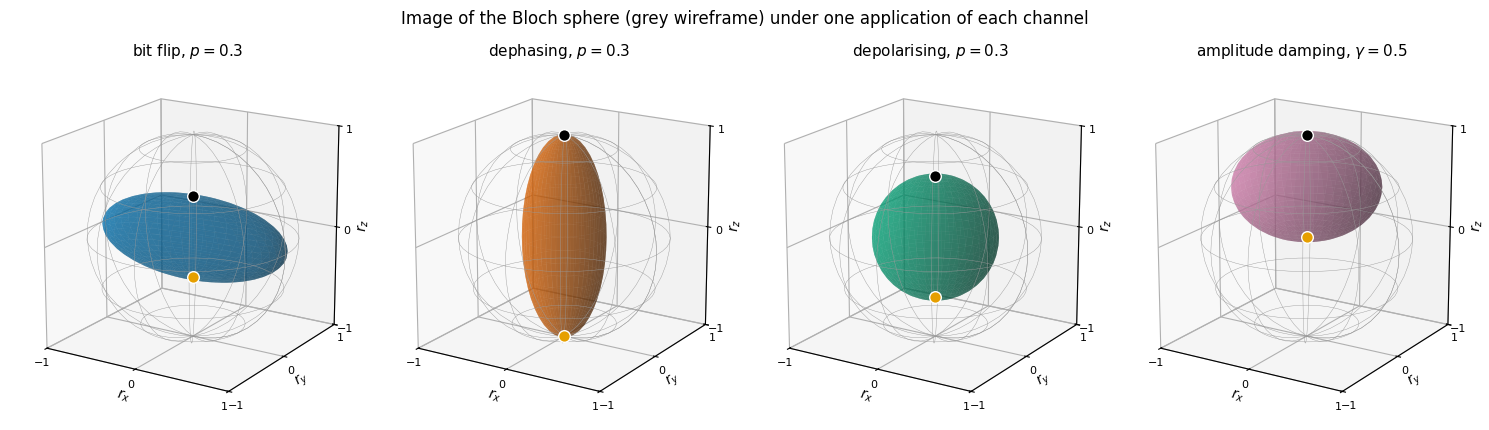

In [22]:
# ==============================================================================
# FIGURE: what each channel does to the Bloch sphere
# ==============================================================================
u, w = np.linspace(0, 2 * np.pi, 49), np.linspace(0, np.pi, 25)
sphere = np.stack([np.outer(np.cos(u), np.sin(w)), np.outer(np.sin(u), np.sin(w)), np.outer(np.ones_like(u), np.cos(w))])

fig, axes = plt.subplots(1, 4, figsize=(15, 4.4), subplot_kw={"projection": "3d"})
titles = {"bit flip": rf"bit flip, $p={p}$", "dephasing": rf"dephasing, $p={p}$",
          "depolarising": rf"depolarising, $p={p}$", "amplitude damping": rf"amplitude damping, $\gamma={g}$"}
for ax, col, (name, (Kc, _, _)) in zip(axes, COLORS, analytic.items()):
    M, cvec = (np.asarray(a) for a in bloch_map(Kc))
    img = np.einsum("ab,bij->aij", M, sphere) + cvec[:, None, None]     # r -> M r + c for every grid point
    ax.computed_zorder = False                                         # draw in zorder: pole markers on top of the surface
    ax.plot_wireframe(*sphere, color="0.6", lw=0.3, rstride=4, cstride=4)
    ax.plot_surface(*img, color=col, alpha=0.55, lw=0)
    for pole, pc in [((0, 0, 1), "k"), ((0, 0, -1), COLORS[4])]:
        ax.scatter(*(M @ np.array(pole) + cvec), color=pc, s=70, edgecolors="white", linewidths=1.0,
                   depthshade=False, zorder=10)
    ax.set_box_aspect((1, 1, 1)); ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_xlabel(r"$r_x$", labelpad=-8); ax.set_ylabel(r"$r_y$", labelpad=-8); ax.set_zlabel(r"$r_z$", labelpad=-8)
    ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1]); ax.set_zticks([-1, 0, 1])
    ax.tick_params(pad=-3, labelsize=8)
    ax.view_init(elev=18, azim=-58)
    ax.set_title(titles[name], fontsize=11)
fig.suptitle("Image of the Bloch sphere (grey wireframe) under one application of each channel", y=0.99)
fig.tight_layout(); plt.show()

**Interpretation.** The bit flip leaves the $x$-axis untouched and squeezes the sphere into a cigar along $x$; dephasing
does the same along $z$ (the poles $|0\rangle,|1\rangle$ are fixed, the equator of superpositions collapses towards the axis);
the depolarising channel shrinks the sphere uniformly by $1-4p/3=0.6$; amplitude damping both shrinks the sphere and
lifts it: the image of the south pole $|1\rangle$ (orange dot) has moved up to the centre of the ball ($r_z=\gamma-(1-\gamma)=0$
at $\gamma=0.5$), while the north pole $|0\rangle$ (black dot) stays where it is.

### 9.4 Two Kraus representations of one channel

Phase damping and dephasing act identically on the Bloch ball if $1-2p=\sqrt{1-\lambda}$: both multiply $r_x,r_y$ by the
same factor and leave $r_z$ alone. Since a single-qubit channel *is* its affine map, they are **the same channel**,
written with different Kraus operators. This is the channel analogue of §2.2 (different ensembles, same $\rho$). The general
statement, quoted without proof (Nielsen & Chuang, Theorem 8.2, "unitary freedom in the operator-sum representation"),
has exactly the shape of the ensemble rule of §2.2: after padding the shorter of the two lists with zero operators so
that both contain $M$ elements, two Kraus sets describe the same channel if and only if $K'_m=\sum_nu_{mn}K_n$ with an
$M\times M$ unitary matrix $u$. The padding is what makes $u$ square. The identity channel, for
instance, is written either as $\{\mathbb 1\}$ or as $\{\cos\alpha\,\mathbb 1,\ \sin\alpha\,\mathbb 1\}$, and the two
lists are related by a $2\times2$ rotation only once the first has been padded to $\{\mathbb 1,\,0\}$.
Physically, $u$ is a change of the basis in which the *environment*
is read out in Eq. (3), which cannot matter for the system. It will matter in §11.3 for the simulation *method*.

In [23]:
# ==============================================================================
# CHECKPOINT: phase damping(lambda) == dephasing(p) when 1 - 2p = sqrt(1 - lambda)
# ==============================================================================
lam = 0.36
p_equiv = (1 - np.sqrt(1 - lam)) / 2
M1, c1 = bloch_map(kraus_phase_damping(lam))
M2, c2 = bloch_map(kraus_dephasing(p_equiv))
err = float(jnp.max(jnp.abs(M1 - M2)) + jnp.max(jnp.abs(c1 - c2)))
print(f"lambda = {lam}  <->  p = {p_equiv:.4f}:  max difference of the Bloch maps = {err:.1e}")
assert err < TOL

# the unitary that connects the two Kraus sets:  K'_m = sum_n u_mn K_n
Kz = kraus_dephasing(p_equiv)                                  # sqrt(1-p) 1, sqrt(p) Z
Kpd = kraus_phase_damping(lam)
u_mix = jnp.einsum("mab,nab->mn", Kpd, jnp.conj(Kz)) / jnp.einsum("nab,nab->n", Kz, jnp.conj(Kz))[None, :]
err_u = float(jnp.max(jnp.abs(u_mix @ u_mix.conj().T - jnp.eye(2))))
err_K = float(jnp.max(jnp.abs(jnp.einsum("mn,nab->mab", u_mix, Kz) - Kpd)))
print(f"mixing matrix u =\n{np.round(np.asarray(u_mix).real, 4)}\nunitarity error {err_u:.1e}, |u K - K'| = {err_K:.1e}")
assert err_u < TOL and err_K < TOL

lambda = 0.36  <->  p = 0.1000:  max difference of the Bloch maps = 1.1e-16
mixing matrix u =
[[ 0.9487  0.3162]
 [ 0.3162 -0.9487]]
unitarity error 4.4e-16, |u K - K'| = 0.0e+00


### 9.5 Repeated noise: decay of purity, entropy and fidelity

Noise in a device acts again and again. Applying a channel $n$ times multiplies the Bloch components by the $n$-th
power of the contraction factors, e.g. $(1-2p)^n=e^{-n/n_2}$ with $n_2=-1/\ln(1-2p)$: **exponential decay**, the discrete
version of the $e^{-t/T_2}$ and $e^{-t/T_1}$ laws measured in Ramsey and relaxation experiments.

We follow a qubit prepared in a generic pure state (Bloch angles $\vartheta=2\pi/3$, $\varphi=\pi/4$, so mostly
$|1\rangle$ with some coherence) through 60 applications of each channel with strength 0.05, recording

* purity $\mathrm{Tr}\rho^2$ and entropy $S(\rho)$: how mixed the state has become;
* **fidelity with the initial state** $F=\langle\psi_0|\rho|\psi_0\rangle$: the probability that a measurement would still find $|\psi_0\rangle$.

> **JAX practice.** A loop "apply the same function $n$ times and record something after each step" is `lax.scan`
> ([notebook 01](../ch01_computational_toolbox/01_jax_from_scratch.ipynb)): `step(carry, x) -> (new_carry, record)`. The step is compiled once,
> instead of being unrolled $n$ times as a Python `for` loop under `jit` would be.

depolarising purity versus analytic (1 + (1-4p/3)^(2n))/2 : max error = 7.5e-15


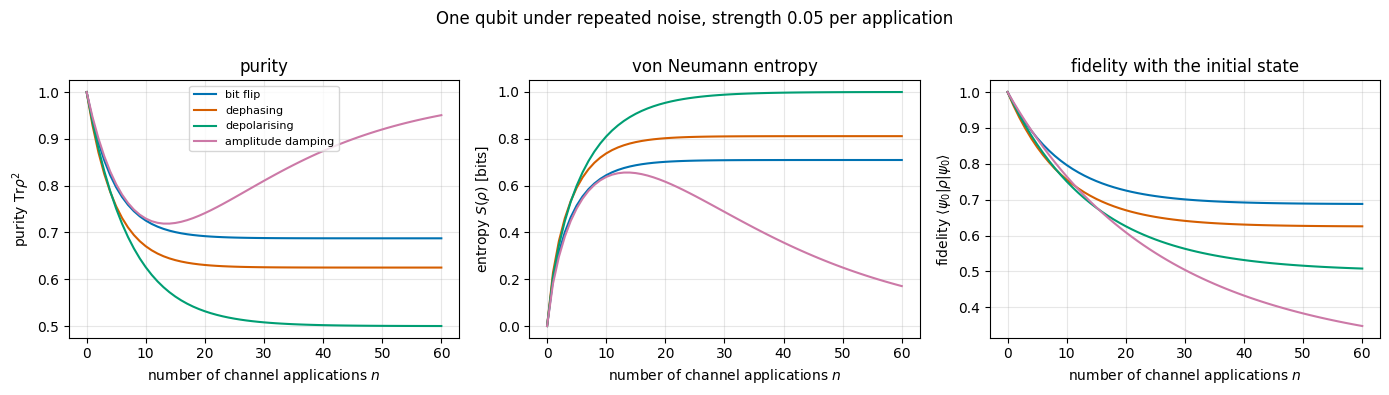

bit flip           after 60 steps: purity = 0.6875, entropy = 0.7094 bit, fidelity = 0.6881
dephasing          after 60 steps: purity = 0.6250, entropy = 0.8113 bit, fidelity = 0.6257
depolarising       after 60 steps: purity = 0.5001, entropy = 0.9998 bit, fidelity = 0.5080
amplitude damping  after 60 steps: purity = 0.9506, entropy = 0.1706 bit, fidelity = 0.3478


In [24]:
# ==============================================================================
# PARAMETERS
# ==============================================================================
n_steps = 60            # number of channel applications
strength = 0.05         # p (or gamma) per application
bloch_theta, bloch_phi = 2 * np.pi / 3, np.pi / 4              # initial pure state on the Bloch sphere

# ==============================================================================
# STEP 10: repeated application of a channel with lax.scan
# ==============================================================================
def fidelity_with_pure(rho, psi):
    """F = <psi| rho |psi> : overlap of a density tensor with a pure target state (both of N qubits).

    IMPLEMENTATION  reshape to matrix/vector: <v| (R v)>  -- one matrix-vector product, O(4^N)."""
    vec = psi.reshape(-1)
    return jnp.real(jnp.vdot(vec, dm_matrix(rho) @ vec))


psi0 = (jnp.cos(bloch_theta / 2) * basis_state([0]) + jnp.exp(1j * bloch_phi) * jnp.sin(bloch_theta / 2) * basis_state([1]))


def decay_curves(kraus):
    """Apply `kraus` n_steps times to |psi0><psi0|; return (purity, entropy, fidelity) after 0..n_steps applications."""
    def diagnostics(rho):
        return jnp.stack([purity(rho), von_neumann_entropy(rho), fidelity_with_pure(rho, psi0)])

    def step(rho, _):
        rho = apply_kraus_dm(rho, kraus, [0])
        return rho, diagnostics(rho)

    rho0 = to_dm(psi0)
    _, rec = lax.scan(step, rho0, None, length=n_steps)
    return jnp.concatenate([diagnostics(rho0)[None], rec])     # prepend the n = 0 values


curves = {name: jax.jit(decay_curves)(fn(strength)) for name, fn in CHANNELS.items() if name != "phase damping"}

# checkpoint: depolarising purity is (1 + (1-4p/3)^(2n))/2 because |r| shrinks by (1-4p/3) per step
n_arr = jnp.arange(n_steps + 1)
err = float(jnp.max(jnp.abs(curves["depolarising"][:, 0] - 0.5 * (1 + (1 - 4 * strength / 3) ** (2 * n_arr)))))
print(f"depolarising purity versus analytic (1 + (1-4p/3)^(2n))/2 : max error = {err:.1e}")
assert err < 100 * TOL

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
for col, (name, rec) in zip(COLORS, curves.items()):
    for ax, j in zip(axes, range(3)):
        ax.plot(n_arr, rec[:, j], color=col, label=name)
for ax, lab in zip(axes, [r"purity $\mathrm{Tr}\rho^2$", r"entropy $S(\rho)$ [bits]", r"fidelity $\langle\psi_0|\rho|\psi_0\rangle$"]):
    ax.set_xlabel("number of channel applications $n$"); ax.set_ylabel(lab)
axes[0].legend(fontsize=8); axes[0].set_title("purity"); axes[1].set_title("von Neumann entropy")
axes[2].set_title("fidelity with the initial state")
fig.suptitle(rf"One qubit under repeated noise, strength {strength} per application", y=1.0)
fig.tight_layout(); plt.show()

for name, rec in curves.items():
    print(f"{name:18s} after {n_steps} steps: purity = {float(rec[-1, 0]):.4f}, entropy = {float(rec[-1, 1]):.4f} bit, fidelity = {float(rec[-1, 2]):.4f}")

**Interpretation.**

* *Depolarising* noise drives the state monotonically to the centre of the ball: purity → ½, entropy → 1 bit, fidelity → ½.
* *Bit flip* and *dephasing* stop half-way: each preserves one Bloch component (the projection of $\mathbf r$ on the $x$-
  or $z$-axis), so the state ends on that axis, inside the ball, with entropy below one bit. The numbers printed above differ
  between the two because our initial state has different $x$- and $z$-components ($r_x\approx0.61$, $r_z=-0.5$).
* *Amplitude damping* is qualitatively different: purity first **drops** (the qubit is entangled with the emitted
  photon) and then **recovers** towards 1 while the entropy returns towards zero: the qubit relaxes to the pure ground
  state $|0\rangle$. Its fidelity with the initial, mostly-$|1\rangle$ state keeps decaying, towards
  $|\langle\psi_0|0\rangle|^2=\cos^2(\vartheta/2)=0.25$ (it has reached 0.35 after 60 steps). Purity measures mixedness;
  closeness to the intended state is measured by the fidelity.

## 10. Many-body physics: a GHZ state under local noise

### 10.1 Setting and analytic expectations

The GHZ state $|\mathrm{GHZ}_N\rangle=(|0\dots0\rangle+|1\dots1\rangle)/\sqrt2$ is the $N$-qubit version of Schrödinger's cat: a
superposition of two macroscopically distinct configurations, and the resource behind Heisenberg-limited metrology
(the subject of [notebook 32](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb) in
Chapter 10). Its density matrix has only four non-zero
entries: two **populations** $\rho[0..0;0..0]=\rho[1..1;1..1]=\tfrac12$ and two **coherences**
$\rho[0..0;1..1]=\rho[1..1;0..0]=\tfrac12$. The populations alone would describe a classical mixture "all up or all down";
the single pair of coherences carries *all* the quantumness.

Now let every qubit suffer independent **local** noise $\mathcal E^{\otimes N}$. We can predict three things.

* **Dephasing on all qubits.** Each $Z_q$ multiplies the coherence $|0..0\rangle\langle1..1|$ by $-1$ and leaves the
  populations alone. Each qubit's channel thus multiplies the coherence by $(1-p)-p=1-2p$, and the $N$ channels together by
  $(1-2p)^N$:

  $$ F_{\rm GHZ}=\langle{\rm GHZ}|\rho|{\rm GHZ}\rangle=\tfrac12\big[1+(1-2p)^N\big],\qquad
     \langle X^{\otimes N}\rangle=(1-2p)^N,\qquad \langle Z_iZ_j\rangle=1. $$

  With $1-2p=e^{-\Delta t/T_\phi}$ the cat's coherence decays as $e^{-N\Delta t/T_\phi}$, **$N$ times faster than a single
  qubit's**. The classical correlation $\langle Z_iZ_j\rangle$ does not decay at all.

  *Where the $N^2$ of the introduction comes from.* Model dephasing as a random phase: a fluctuating field gives qubit
  $q$ the factor $e^{-i\varphi_q/2}$ on $|0\rangle$ and $e^{+i\varphi_q/2}$ on $|1\rangle$ (a random $R_z(\varphi_q)$).
  The coherence $|0\dots0\rangle\langle1\dots1|$ collects the phase of the ket *and* the conjugate phase of the bra,
  $\prod_q e^{-i\varphi_q/2}\cdot\prod_q e^{-i\varphi_q/2}=e^{-i\sum_q\varphi_q}$, which we must then average over the
  noise. If the $\varphi_q$ are **independent** zero-mean Gaussians of variance $\sigma^2$, their sum has variance
  $N\sigma^2$ and $\mathbb E\,e^{-i\sum_q\varphi_q}=e^{-N\sigma^2/2}$. This is exactly our product channel: one qubit
  gives $1-2p=e^{-\sigma^2/2}$, and $N$ of them give $(1-2p)^N$. If instead the *same* field fluctuation hits every
  qubit, $\varphi_q=\varphi$ for all $q$, then $\sum_q\varphi_q=N\varphi$ has variance $N^2\sigma^2$ and the coherence
  decays as $e^{-N^2\sigma^2/2}$ — the "superdecoherence" of the ion experiments quoted in the introduction. Such
  correlated noise is *not* a product channel $\mathcal E^{\otimes N}$ and is not simulated below.
* **Bit flips on all qubits.** A pattern of flips maps GHZ to an orthogonal state unless no qubit or *all* qubits are
  flipped ($X^{\otimes N}|{\rm GHZ}\rangle=|{\rm GHZ}\rangle$). Hence $F_{\rm GHZ}=(1-p)^N+p^N$.
* **Entanglement.** We quantify the entanglement between qubit 0 and the rest by the **negativity**: transpose only
  the indices of qubit 0 ("partial transpose") and add up the absolute values of the negative eigenvalues of the
  result. For any unentangled (separable) state the partial transpose is again a valid state and the negativity vanishes:
  if $\rho=\sum_kp_k\,\rho_A^{(k)}\otimes\rho_B^{(k)}$ then the partial transpose is
  $\sum_kp_k\,(\rho_A^{(k)})^{\mathrm T}\otimes\rho_B^{(k)}$, and transposing a density matrix leaves its eigenvalues
  alone. A negative eigenvalue therefore certifies entanglement — and it is possible only because transposition is
  positive but *not* completely positive (§7.2). In tensor form the partial transpose is a swap of the ket axis $q$ with the bra axis $N+q$,
  one `jnp.transpose`. The engine's `partial_transpose` (shown below) first passes its argument through `as_dm_tensor`,
  which reshapes a $(2^N,2^N)$ matrix such as the output of `rdm` or `dm_matrix` into the rank-$2N$ tensor. Without that
  step a matrix would have only two axes, the "swap" would transpose the whole matrix, the eigenvalues would not change,
  and the negativity would come out as exactly zero for every state. The details and proofs belong to notebook 25 of Chapter 9 (Peres 1996; Vidal & Werner 2002, see the
  references); here we use it as a ready-made thermometer. For the dephased GHZ state the partial transpose moves the coherence
  $\tfrac c2$, $c=(1-2p)^N$, to a $2\times2$ block between the *unpopulated* basis states $|10..0\rangle,|01..1\rangle$; its
  eigenvalues are $\pm\tfrac c2$, so $\mathcal N=\tfrac12(1-2p)^N$.

In [25]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def as_dm_tensor(rho):
    """Accept a density matrix in EITHER form and return the rank-2N tensor (2,)*2N.

    Both conventions are in use: `rdm` and `dm_matrix` return a (2^N, 2^N) MATRIX, while
    `to_dm` and the channel functions work with the rank-2N TENSOR (N ket axes, then N bra axes).
    A (2^N, 2^N) matrix with N > 1 is unambiguous, because a density tensor has every axis of length 2.
    Passing the matrix form straight to `partial_transpose` used to transpose the WHOLE matrix, which
    leaves the eigenvalues alone and silently reports zero negativity -- hence this conversion.
    """
    rho = jnp.asarray(rho)
    if rho.ndim == 2 and rho.shape[0] > 2:                  # (2^N, 2^N) matrix with N > 1
        d = rho.shape[0]
        N = int(round(math.log2(d)))
        if 2 ** N != d:
            raise ValueError(f"density matrix of dimension {d} is not a power of two")
        return rho.reshape((2,) * (2 * N))
    if any(s != 2 for s in rho.shape) or rho.ndim % 2:
        raise ValueError(f"not a density matrix or density tensor: shape {rho.shape}")
    return rho

def partial_transpose(rho, qubits):
    """Partial transpose on subsystem A = `qubits`, for a density tensor OR a (2^N, 2^N) matrix.
    In tensor form it is trivial: SWAP the ket axis q with the bra axis N+q for q in A.
    (With a 2^N x 2^N matrix this requires painful index gymnastics -- here: one `transpose`.)
    RETURNS the rank-2N tensor; wrap in `dm_matrix` for the matrix form."""
    rho = as_dm_tensor(rho)
    N = rho.ndim // 2
    perm = list(range(2 * N))
    for q in qubits:
        perm[q], perm[N + q] = perm[N + q], perm[q]
    return jnp.transpose(rho, perm)

def negativity(rho, qubits):
    """Entanglement negativity (Peres-Horodecki / PPT criterion).
        N(rho) = (||rho^{T_A}||_1 - 1)/2 = sum of |negative eigenvalues| of the partial transpose,
        E_N    = log2 ||rho^{T_A}||_1 = log2(2N+1)      (logarithmic negativity).
    N > 0  =>  entangled (for 2x2 and 2x3 systems also <=).   Returns (N, E_N)."""
    lam = jnp.linalg.eigvalsh(dm_matrix(partial_transpose(rho, qubits)))
    neg = jnp.sum(jnp.abs(lam) - lam) / 2
    return neg, jnp.log2(2 * neg + 1)


In [26]:
# ==============================================================================
# STEP 11: local noise on every qubit of a density tensor
# ==============================================================================
def apply_kraus_all_dm(rho, kraus):
    """The product channel E x E x ... x E: the same single-qubit channel on every qubit.

    IMPLEMENTATION  N calls of `apply_kraus_dm`; cost O(N 4^N): inside each call the sum over the M Kraus operators is
    done FIRST, on 2x2 blocks (section 12.3), so M does not multiply the cost of the passes over rho.  (The equivalent
    global Kraus description would need M^N operators of size 2^N x 2^N -- locality is what keeps noise simulable.)"""
    for q in range(rho.ndim // 2):
        rho = apply_kraus_dm(rho, kraus, [q])
    return rho


# ==============================================================================
# CHECKPOINT: one channel on ONE qubit (p = 0.2 on qubit 0) of a 6-qubit GHZ state
# ==============================================================================
N, p = 6, 0.2
ghz = ghz_state(N)
rho_ghz = to_dm(ghz)
print(f"GHZ_{N}: density tensor of rank {rho_ghz.ndim} with {rho_ghz.size} entries, "
      f"{int(jnp.sum(jnp.abs(rho_ghz) > 0))} of them non-zero\n")
print(f"{'channel on qubit 0':20s} {'<Z_0>':>8s} {'<Z_0 Z_5>':>10s} {'<X..X>':>8s} {'Tr rho':>8s} {'purity':>8s} {'S [bit]':>8s} {'F_GHZ':>8s}")
zz_string = "Z" + "I" * (N - 2) + "Z"
dm_table = {}
for name, fn in CHANNELS.items():
    out = apply_kraus_dm(rho_ghz, fn(p), [0])
    Rm = dm_matrix(out)
    row = [float(expect_local_dm(out, Z, [0])), float(expect_pauli_string_dm(out, zz_string)),
           float(expect_pauli_string_dm(out, "X" * N)), float(jnp.real(jnp.trace(Rm))), float(purity(Rm)),
           float(von_neumann_entropy(Rm)), float(fidelity_with_pure(out, ghz))]
    dm_table[name] = row
    print(f"{name:20s} " + " ".join(f"{v:>+8.4f}" if i == 0 else (f"{v:>+10.4f}" if i == 1 else f"{v:>8.4f}") for i, v in enumerate(row)))

assert abs(dm_table["dephasing"][2] - (1 - 2 * p)) < TOL          # <X..X> = 1 - 2p for one dephased qubit
assert abs(dm_table["dephasing"][6] - 0.5 * (1 + (1 - 2 * p))) < TOL
assert abs(dm_table["amplitude damping"][0] - p) < TOL             # <Z_0> = gamma: r_z -> gamma + (1-gamma) r_z with r_z = 0
assert all(abs(r[3] - 1) < TOL for r in dm_table.values())        # every channel preserves the trace

GHZ_6: density tensor of rank 12 with 4096 entries, 4 of them non-zero

channel on qubit 0      <Z_0>  <Z_0 Z_5>   <X..X>   Tr rho   purity  S [bit]    F_GHZ


bit flip              +0.0000    +0.6000   1.0000   1.0000   0.6800   0.7219   0.8000
dephasing             +0.0000    +1.0000   0.6000   1.0000   0.6800   0.7219   0.8000
depolarising          +0.0000    +0.7333   0.7333   1.0000   0.6533   1.0389   0.8000
amplitude damping     +0.2000    +0.8000   0.8944   1.0000   0.8200   0.4690   0.8972
phase damping         +0.0000    +1.0000   0.8944   1.0000   0.9000   0.2981   0.9472


**Reading the table** (one channel of strength 0.2 acting on qubit 0 only):

* **A single noisy qubit damages the whole state.** Dephasing one qubit reduces the $N$-body coherence
  $\langle X^{\otimes N}\rangle$ from 1 to $1-2p=0.6$ and the fidelity to $0.8$. The GHZ coherence is a *collective*
  property, and every qubit holds a veto over it.
* Dephasing (and phase damping) cannot touch the classical correlation: $\langle Z_0Z_5\rangle=1$ exactly. A *bit flip*
  does the opposite: it reduces $\langle Z_0Z_5\rangle$ to $1-2p$ because it changes which basis state qubit 0 is in,
  but leaves $\langle X^{\otimes N}\rangle=1$ since $X_0$ commutes with $X^{\otimes N}$. Its purity, entropy and fidelity
  are identical to those of dephasing: both mix the GHZ state with *one* orthogonal state with weights $(0.8,0.2)$.
* *Depolarising* noise reduces both; *amplitude damping* also reduces both and in addition creates a magnetisation
  $\langle Z_0\rangle=\gamma$ by moving population from $|1\rangle$ to $|0\rangle$ on qubit 0 (Bloch map of §9.3 with $r_z=0$).
* *Phase damping* with $\lambda=0.2$ is a weaker dephasing ($\sqrt{1-\lambda}\approx0.894$ against $1-2p=0.6$). The same
  number 0.2 means different physics in different parametrisations.
* $\mathrm{Tr}\rho=1$ always; purity $<1$ and entropy $>0$: the state is now mixed.

**Sweep over the noise strength, all qubits noisy.** We compute fidelity, purity, entropy and negativity as functions of
$p$ with **one compiled, vectorised call per channel**: `jax.vmap` maps the function "noise strength → diagnostics"
over an array of strengths, `jax.jit` compiles the batch. The Kraus constructors accept traced values of $p$, so the
*whole pipeline* (Kraus operators → $N$ einsums → eigenvalues) is traced once.

In [27]:
# ==============================================================================
# PARAMETERS
# ==============================================================================
N_sweep = 6                                        # GHZ size for the channel comparison (density tensor: 4^6 = 4096 entries)
p_grid = jnp.linspace(0.0, 0.5, 26)                # noise strength per qubit
sizes = (1, 2, 4, 6, 8)                            # GHZ sizes for the dephasing-versus-N panel

# ==============================================================================
# STEP 12: GHZ diagnostics as a function of the noise strength -- jit(vmap(...)) over p
# ==============================================================================
def ghz_diagnostics(kraus_fn, p, N):
    """(fidelity with GHZ, purity, entropy, negativity of the cut {0}|rest) after the channel on ALL qubits."""
    target = ghz_state(N)
    rho = apply_kraus_all_dm(to_dm(target), kraus_fn(p))
    Rm = dm_matrix(rho)
    return jnp.stack([fidelity_with_pure(rho, target), purity(Rm), von_neumann_entropy(Rm), negativity(rho, [0])[0]])


t0 = time.perf_counter()
sweeps = {}
for name, fn in CHANNELS.items():
    if name == "phase damping":
        continue                                   # same channel as dephasing (section 9.4)
    sweeps[name] = jax.jit(jax.vmap(lambda p, fn=fn: ghz_diagnostics(fn, p, N_sweep)))(p_grid)
fid_vs_N = {n: jax.jit(jax.vmap(lambda p, n=n: ghz_diagnostics(kraus_dephasing, p, n)[0]))(p_grid) for n in sizes}
jax.block_until_ready(fid_vs_N)
print(f"{len(sweeps)} channel sweeps (N = {N_sweep}) + {len(sizes)} size sweeps, {p_grid.size} noise strengths each: "
      f"{time.perf_counter() - t0:.1f} s including compilation")

# ---- checkpoints against the analytic results of section 10.1 ----------------------------------------------------
err_deph = max(float(jnp.max(jnp.abs(fid_vs_N[n] - 0.5 * (1 + (1 - 2 * p_grid) ** n)))) for n in sizes)
err_flip = float(jnp.max(jnp.abs(sweeps["bit flip"][:, 0] - ((1 - p_grid) ** N_sweep + p_grid ** N_sweep))))
err_neg = float(jnp.max(jnp.abs(sweeps["dephasing"][:, 3] - 0.5 * (1 - 2 * p_grid) ** N_sweep)))
print(f"dephasing: F = (1 + (1-2p)^N)/2           max error = {err_deph:.1e}")
print(f"bit flip : F = (1-p)^N + p^N              max error = {err_flip:.1e}")
print(f"dephasing: negativity = (1-2p)^N / 2      max error = {err_neg:.1e}")
assert max(err_deph, err_flip, err_neg) < 100 * TOL

4 channel sweeps (N = 6) + 5 size sweeps, 26 noise strengths each: 1.6 s including compilation


dephasing: F = (1 + (1-2p)^N)/2           max error = 1.1e-15
bit flip : F = (1-p)^N + p^N              max error = 7.8e-16
dephasing: negativity = (1-2p)^N / 2      max error = 2.8e-16


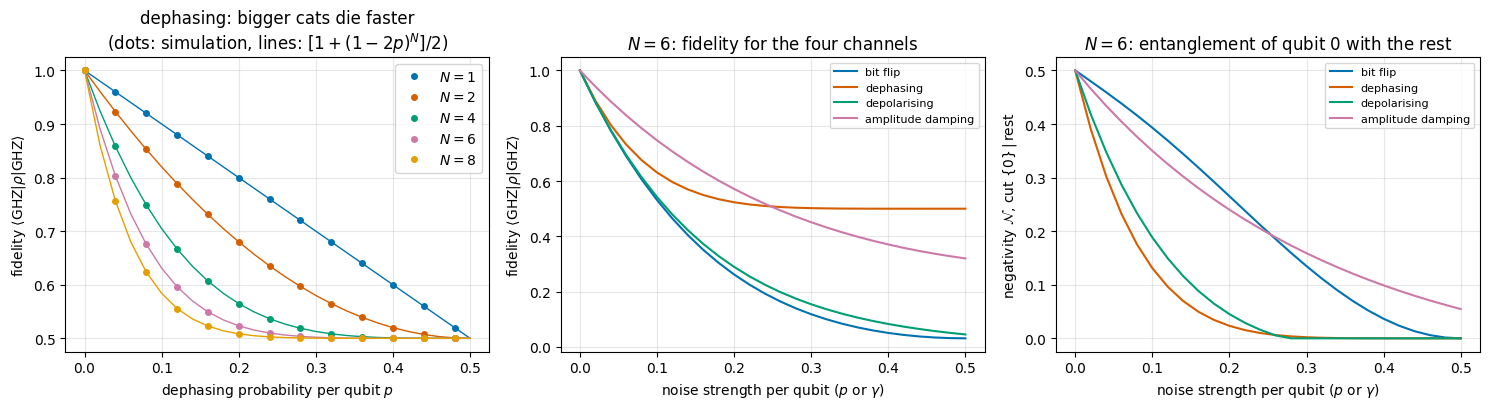

at strength 0.10 per qubit, N = 6:
  bit flip           F = 0.531  purity = 0.304  S = 2.789 bit  negativity = 0.393
  dephasing          F = 0.631  purity = 0.534  S = 0.950 bit  negativity = 0.131
  depolarising       F = 0.542  purity = 0.315  S = 2.901 bit  negativity = 0.188
  amplitude damping  F = 0.747  purity = 0.592  S = 1.694 bit  negativity = 0.350
smallest grid value of the noise strength at which the negativity is zero (below 1e-9):
  bit flip           0.50
  dephasing          0.50
  depolarising       0.28
  amplitude damping  never on this grid (p <= 0.5)


In [28]:
# ==============================================================================
# FIGURE: GHZ state under local noise on every qubit
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axes[0]
for col, n in zip(COLORS, sizes):
    ax.plot(p_grid, 0.5 * (1 + (1 - 2 * p_grid) ** n), color=col, lw=1)
    ax.plot(p_grid[::2], fid_vs_N[n][::2], "o", color=col, ms=4, label=f"$N={n}$")
ax.set_xlabel("dephasing probability per qubit $p$"); ax.set_ylabel(r"fidelity $\langle\mathrm{GHZ}|\rho|\mathrm{GHZ}\rangle$")
ax.set_title("dephasing: bigger cats die faster\n(dots: simulation, lines: $[1+(1-2p)^N]/2$)"); ax.legend()
for ax, j, lab in [(axes[1], 0, r"fidelity $\langle\mathrm{GHZ}|\rho|\mathrm{GHZ}\rangle$"),
                   (axes[2], 3, r"negativity $\mathcal{N}$, cut $\{0\}\,|\,$rest")]:
    for col, (name, rec) in zip(COLORS, sweeps.items()):
        ax.plot(p_grid, rec[:, j], color=col, label=name)
    ax.set_xlabel(r"noise strength per qubit ($p$ or $\gamma$)"); ax.set_ylabel(lab); ax.legend(fontsize=8)
axes[1].set_title(f"$N={N_sweep}$: fidelity for the four channels")
axes[2].set_title(f"$N={N_sweep}$: entanglement of qubit 0 with the rest")
fig.tight_layout(); plt.show()

i10 = int(jnp.argmin(jnp.abs(p_grid - 0.1)))
print(f"at strength {float(p_grid[i10]):.2f} per qubit, N = {N_sweep}:")
for name, rec in sweeps.items():
    print(f"  {name:18s} F = {float(rec[i10, 0]):.3f}  purity = {float(rec[i10, 1]):.3f}  S = {float(rec[i10, 2]):.3f} bit  negativity = {float(rec[i10, 3]):.3f}")
print("smallest grid value of the noise strength at which the negativity is zero (below 1e-9):")
for name, rec in sweeps.items():
    dead = np.flatnonzero(np.asarray(rec[:, 3]) < 1e-9)
    print(f"  {name:18s} " + (f"{float(p_grid[dead[0]]):.2f}" if dead.size else "never on this grid (p <= 0.5)"))

**Interpretation.**

* *Left:* the simulation (dots) follows $[1+(1-2p)^N]/2$ (lines). For a single qubit the fidelity falls linearly in $p$;
  for $N=8$ it has essentially reached its floor of ½ at $p\approx0.2$. The floor is the classical mixture
  $\tfrac12(|0..0\rangle\langle0..0|+|1..1\rangle\langle1..1|)$, which still overlaps 50 % with the GHZ state: a fidelity
  above ½ is therefore the usual experimental criterion for genuine GHZ entanglement.
* *Middle:* at equal nominal strength the four channels hurt the GHZ state differently (the numbers at strength 0.1 are
  printed under the figure). Dephasing has the ½ floor because it cannot touch the populations. The other channels
  scramble the populations as well, so their fidelity keeps falling below ½: bit flips follow $F=(1-p)^N+p^N$, which is
  only $2^{1-N}\approx0.03$ at $p=0.5$.
* *Right:* the negativity starts at ½ (the value of a maximally entangled pair of qubits) and decays with the noise
  strength. For dephasing it follows $\tfrac12(1-2p)^N$ exactly (checked above): it is tiny beyond $p\approx0.25$ but
  vanishes only at $p=0.5$. Under depolarising noise it reaches zero already at a *finite* noise strength (see the last
  lines of the printout), a phenomenon known as "sudden death" of entanglement.
* Compare the bit-flip curves in the two panels: its *fidelity* falls fastest of all four channels, yet up to
  $p\approx0.25$ its *negativity* is the **largest** of the four (beyond that amplitude damping, which is not a Pauli
  channel and pulls the state towards the pure $|0\dots0\rangle$, overtakes it and is the only channel with a non-zero
  negativity at $p=0.5$).
  A bit-flip pattern maps the GHZ state to another GHZ-like state $(|s\rangle+|\bar s\rangle)/\sqrt2$ ($\bar s$ = complement of
  the bit string $s$), which is orthogonal to the target but just as entangled. Fidelity with the target and the
  entanglement that remains are different figures of merit, and they can rank the same channels in opposite order.

## 11. Stochastic unravelling: channels on pure states

### 11.1 The idea and the proof

The density tensor costs $4^N$ numbers. Noise can also be simulated with state vectors of $2^N$ numbers, at the price
of randomness. Recall that the Kraus index $m$ labels what the environment could have recorded. Imagine that somebody
*does* look at the environment after every channel. Given the pure state $|\psi\rangle$, record $m$ occurs with probability

$$ p_m=\|K_m|\psi\rangle\|^2=\langle\psi|K_m^\dagger K_m|\psi\rangle,\qquad\sum_mp_m=\langle\psi|\textstyle\sum_mK_m^\dagger K_m|\psi\rangle=1\quad\text{(completeness, Eq. 4)}, $$

and the system is left in the **pure** state

$$ |\psi\rangle\;\to\;|\psi_m\rangle=\frac{K_m|\psi\rangle}{\sqrt{p_m}} . $$

One random sequence of records defines a **quantum trajectory**. Since *we* do not look at the environment, our state is
the ensemble of all trajectories. Its density operator after one step is, by Eq. (1),

$$ \mathbb E\big[|\psi_m\rangle\langle\psi_m|\big]=\sum_mp_m\,\frac{K_m|\psi\rangle\langle\psi|K_m^\dagger}{p_m}
   =\sum_mK_m|\psi\rangle\langle\psi|K_m^\dagger=\mathcal E\big(|\psi\rangle\langle\psi|\big).\qquad\text{(Eq. 5)} $$

The probabilities cancel against the normalisation. **The average over trajectories reproduces the channel exactly**,
for any Kraus operators, unitary or not. (The sum runs over the branches with $p_m>0$; a branch with $p_m=0$ never
occurs, leaves $|\psi_m\rangle$ undefined, and contributes $K_m|\psi\rangle\langle\psi|K_m^\dagger=0$ to the right-hand
side, so it may be dropped from both sides.)

*Many channels in a row (induction).* Let $\rho_t=\mathbb E[|\psi_t\rangle\langle\psi_t|]$ be the trajectory average after $t$
channels. Conditioned on $|\psi_t\rangle$, Eq. (5) gives $\mathbb E[|\psi_{t+1}\rangle\langle\psi_{t+1}|\,\big|\,\psi_t]=\mathcal E(|\psi_t\rangle\langle\psi_t|)$. Averaging
over $|\psi_t\rangle$ and using the **linearity** of $\mathcal E$: $\rho_{t+1}=\mathcal E(\mathbb E[|\psi_t\rangle\langle\psi_t|])=\mathcal E(\rho_t)$.
Unitary gates between the channels are the special case of a single Kraus operator. Hence, for a whole noisy circuit and
any observable,

$$ \mathrm{Tr}(\rho\,O)=\mathbb E\big[\langle\psi|O|\psi\rangle\big]\approx\frac1M\sum_{i=1}^M\langle\psi^{(i)}|O|\psi^{(i)}\rangle,\qquad
   \text{standard error}=\frac{\sigma_O}{\sqrt M}, $$

where $\sigma_O^2$ is the variance of $\langle\psi|O|\psi\rangle$ over trajectories (at most 1 for a Pauli observable). This
is a Monte-Carlo method: the error decreases as $1/\sqrt M$ **independently of $N$**. It is known as the *Monte-Carlo
wave-function* (MCWF) or *quantum-jump* method (Dalibard, Castin & Mølmer 1992; Carmichael 1993; review: Plenio & Knight 1998); its continuous-time
version is developed in [notebook 17](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb), Chapter 6.

### 11.2 From formula to code

For a channel on qubit $q$ of an $N$-qubit state, one step of one trajectory is:

1. compute the $M_K$ candidate states $K_m|\psi\rangle$ with `apply_gate` and their squared norms $p_m$;
2. draw $m$ from the distribution $(p_m)$ with `jax.random.categorical(key, log p)`;
3. return $K_m|\psi\rangle/\sqrt{p_m}$.

We write exactly this first. The engine version then removes the waste of step 1: since
$p_m=\langle\psi|K_m^\dagger K_m|\psi\rangle=\mathrm{Tr}(K_m\rho_qK_m^\dagger)$ is a *local* expectation value, the $2\times2$ reduced
density matrix $\rho_q$ = `rdm(psi, [q])` suffices (einsum `"mab,bc,mac->m"` with operands $K,\rho_q,K^*$), and only the
*chosen* $K_m$ is applied to the big state.

> **JAX practice.** Random numbers in JAX are explicit: every random decision consumes a `key`, and new keys are made
> with `jax.random.split`. Same key, same trajectory, so stochastic simulations are reproducible and can be
> parallelised safely (one key per trajectory). The selection `K[m]` with a *traced* integer `m` is a gather and involves
> no Python `if`, so the function stays compatible with `jit` and `vmap`.

In [29]:
# ==============================================================================
# STEP 13: one stochastic Kraus step, by hand (all branches are computed explicitly)
# ==============================================================================
def kraus_step_by_hand(key, psi, kraus, q):
    """One trajectory step for a single-qubit channel on qubit q.  Returns (new state, chosen branch m, probabilities).

    MATH   p_m = ||K_m psi||^2 ;  draw m ~ p ;  psi -> K_m psi / sqrt(p_m).
    """
    kraus = jnp.asarray(kraus, dtype=CDTYPE)
    branches = jnp.stack([apply_gate(psi, kraus[m], [q]) for m in range(kraus.shape[0])])   # (M_K, 2, ..., 2)
    probs = jnp.sum(jnp.abs(branches.reshape(kraus.shape[0], -1)) ** 2, axis=1)             # p_m = ||K_m psi||^2
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))                 # clip: log(0) -> very negative
    return branches[m] / jnp.sqrt(probs[m]), m, probs


# ---- deterministic checkpoint of Eq. (5): sum over ALL branches, weighted by p_m, equals the channel -----------------
N, q = 3, 1
psi = haar_state(jax.random.PRNGKey(31), N)
Kc = kraus_amplitude_damping(0.3)
branches = [apply_gate(psi, Kc[m], [q]) for m in range(2)]
probs = [float(jnp.sum(jnp.abs(b) ** 2)) for b in branches]
rho_avg = sum(pm * to_dm(b / np.sqrt(pm)) for pm, b in zip(probs, branches))                # sum_m p_m |psi_m><psi_m|
err = float(jnp.max(jnp.abs(rho_avg - apply_kraus_dm(to_dm(psi), Kc, [q]))))
print(f"branch probabilities p_m = {np.round(probs, 6)}, sum = {sum(probs):.12f}")
print(f"sum_m p_m |psi_m><psi_m|  versus  apply_kraus_dm : max diff = {err:.1e}")
assert err < TOL and abs(sum(probs) - 1) < TOL

# the probabilities from the small reduced density matrix (the engine's shortcut) agree with the branch norms
probs_rdm = jnp.real(jnp.einsum("mab,bc,mac->m", Kc, rdm(psi, [q]), jnp.conj(Kc)))
print(f"p_m from the 2x2 reduced density matrix: {np.round(np.asarray(probs_rdm), 6)}")
assert float(jnp.max(jnp.abs(probs_rdm - jnp.array(probs)))) < TOL

branch probabilities p_m = [0.824211 0.175789], sum = 1.000000000000
sum_m p_m |psi_m><psi_m|  versus  apply_kraus_dm : max diff = 3.1e-17
p_m from the 2x2 reduced density matrix: [0.824211 0.175789]


In [30]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def apply_kraus_mcwf(key, psi, kraus, qubits):
    """Apply a channel to a PURE state stochastically (quantum trajectory / Monte-Carlo wave function).

    MATH   choose branch m with probability  p_m = ||K_m psi||^2 = Tr(K_m rho_A K_m^dag)
           then  |psi> -> K_m|psi> / sqrt(p_m).
           Averaging |psi><psi| over many trajectories gives exactly  sum_m K_m rho K_m^dag.
    WHY    memory O(2^N) instead of O(4^N): open systems at the price of closed ones (times #trajectories,
           which are embarrassingly parallel -> jax.vmap over keys).
    IMPLEMENTATION   probabilities come from the SMALL reduced density matrix (einsum "mab,bc,mac->m");
           `K[m]` with a traced integer m is a gather, so everything stays jit-compatible.
    """
    K = jnp.asarray(kraus, dtype=CDTYPE)
    r = rdm(psi, qubits)
    probs = jnp.real(jnp.einsum("mab,bc,mac->m", K, r, jnp.conj(K)))
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))
    psi = apply_gate(psi, K[m], qubits)
    return psi / jnp.linalg.norm(psi)


**Checkpoint: the two simplest experiments.** (i) Bit flip with $p=0.3$ on $|0\rangle$: every trajectory ends in $|0\rangle$ or
$|1\rangle$ with $\langle Z\rangle=\pm1$, and the exact average is $1-2p=0.4$. (ii) Amplitude damping with $\gamma=0.4$ on
$|1\rangle$: exact $\langle Z\rangle=2\gamma-1=-0.2$. We run $10^5$ trajectories *in parallel* with `jax.vmap` over an
array of keys, estimate $\langle Z\rangle$ from the first $M$ of them, and compare with the exact value **in units of its standard error** $\mathrm{SE}=\mathrm{std}/\sqrt M$. A correct
code gives deviations of order one SE, and values beyond 4 SE would be alarming. A test of this kind is only worth
something if a wrong code fails it, so the cell also runs a deliberately broken sampler that draws the branch $m$
uniformly instead of with probability $p_m$ (forgetting the Born weights). Its averages are $0$ in both experiments
(bit flip: $\tfrac12(+1)+\tfrac12(-1)$; amplitude damping: $K_0|1\rangle\propto|1\rangle$ and $K_1|1\rangle\propto|0\rangle$
with equal frequency), and the same $4.5$ SE criterion must reject it.

In [31]:
# ==============================================================================
# CHECKPOINT: trajectory averages on one qubit versus the exact channel
# ==============================================================================
M_max = 100_000

@jax.jit
def mcwf_Z_values(key, psi0, kraus):
    """<Z_0> of M_max independent single-step trajectories: vmap over an array of keys, compiled once."""
    def one_trajectory(k):
        psi = apply_kraus_mcwf(k, psi0, kraus, [0])
        return jnp.real(jnp.vdot(psi, apply_gate(psi, Z, [0])))
    return jax.vmap(one_trajectory)(jax.random.split(key, M_max))


tests = [("bit flip p=0.3 on |0>", basis_state([0]), kraus_bit_flip(0.3), 1 - 2 * 0.3),
         ("ampl. damping g=0.4 on |1>", basis_state([1]), kraus_amplitude_damping(0.4), 2 * 0.4 - 1)]
key = jax.random.PRNGKey(42)
for label, psi0_, Kc, exact in tests:
    exact_dm = float(expect_local_dm(apply_kraus_dm(to_dm(psi0_), Kc, [0]), Z, [0]))
    assert abs(exact_dm - exact) < TOL
    print(f"{label}:  exact <Z> = {exact_dm:+.6f}")
    key, sub = jax.random.split(key)
    vals = mcwf_Z_values(sub, psi0_, Kc)                        # one batch of 100 000 trajectories ...
    for M in (100, 1_000, 10_000, 100_000):
        mean, se = jnp.mean(vals[:M]), jnp.std(vals[:M]) / np.sqrt(M)   # ... analysed with its first M members
        dev = abs(float(mean) - exact_dm)
        print(f"   M = {M:>7d}:  <Z> = {float(mean):+.5f} +- {float(se):.5f}   |error| = {dev:.5f} = {dev / float(se):.2f} SE")
        assert dev < 4.5 * float(se)


# ---- wrong control: a sampler that forgets the Born weights must FAIL the same test ------------------------------
def apply_kraus_uniform(key, psi, kraus, qubits):
    """DELIBERATELY WRONG unravelling: branch m drawn with probability 1/M_K instead of p_m = ||K_m psi||^2."""
    K = jnp.asarray(kraus, dtype=CDTYPE)
    m = jax.random.randint(key, (), 0, K.shape[0])
    psi = apply_gate(psi, K[m], qubits)
    return psi / jnp.linalg.norm(psi)


@jax.jit
def uniform_Z_values(key, psi0, kraus):
    def one_trajectory(k):
        psi = apply_kraus_uniform(k, psi0, kraus, [0])
        return jnp.real(jnp.vdot(psi, apply_gate(psi, Z, [0])))
    return jax.vmap(one_trajectory)(jax.random.split(key, M_max))


print("\nwrong control (branches drawn uniformly, Born weights forgotten), M = 100 000:")
for label, psi0_, Kc, exact in tests:
    key, sub = jax.random.split(key)
    vals = uniform_Z_values(sub, psi0_, Kc)
    z_wrong = abs(float(jnp.mean(vals)) - exact) / (float(jnp.std(vals)) / np.sqrt(M_max))
    print(f"   {label}:  <Z> = {float(jnp.mean(vals)):+.5f}, {z_wrong:.0f} SE from the exact value")
    assert z_wrong > 4.5                                        # the test detects the bug

bit flip p=0.3 on |0>:  exact <Z> = +0.400000


   M =     100:  <Z> = +0.46000 +- 0.08879   |error| = 0.06000 = 0.68 SE
   M =    1000:  <Z> = +0.38600 +- 0.02917   |error| = 0.01400 = 0.48 SE
   M =   10000:  <Z> = +0.39560 +- 0.00918   |error| = 0.00440 = 0.48 SE


   M =  100000:  <Z> = +0.40200 +- 0.00290   |error| = 0.00200 = 0.69 SE
ampl. damping g=0.4 on |1>:  exact <Z> = -0.200000
   M =     100:  <Z> = -0.08000 +- 0.09968   |error| = 0.12000 = 1.20 SE
   M =    1000:  <Z> = -0.24200 +- 0.03068   |error| = 0.04200 = 1.37 SE
   M =   10000:  <Z> = -0.19660 +- 0.00980   |error| = 0.00340 = 0.35 SE
   M =  100000:  <Z> = -0.20444 +- 0.00310   |error| = 0.00444 = 1.43 SE

wrong control (branches drawn uniformly, Born weights forgotten), M = 100 000:


   bit flip p=0.3 on |0>:  <Z> = +0.00084, 126 SE from the exact value
   ampl. damping g=0.4 on |1>:  <Z> = -0.00080, 63 SE from the exact value


The estimates scatter around the exact values by about one standard error, and the standard error itself shrinks by
$\sqrt{10}\approx3.2$ for every tenfold increase of $M$. Look at the printed deviations in units of SE: they are of order
one at every $M$ (largest 1.43), which is the signature of an unbiased estimator with correctly estimated error bars.
The broken sampler, analysed with exactly the same criterion, misses the exact values by 126 and 63 standard errors,
so the test has the power to detect a wrong unravelling.

### 11.3 Same channel, different trajectories

§9.4 showed that dephasing with $1-2p=\sqrt{1-\lambda}$ and phase damping with $\lambda$ are the same channel. Their
*trajectories* are nevertheless completely different. Take $|+\rangle$:

* dephasing Kraus set $\{\sqrt{1-p}\,\mathbb 1,\sqrt p\,Z\}$: the state stays $|+\rangle$ or jumps to $|-\rangle$; $\langle X\rangle=\pm1$ in every trajectory;
* phase-damping set: with probability $\lambda/2$ the qubit collapses to $|1\rangle$ ($\langle X\rangle=0$), otherwise it is
  *slightly* rotated towards $|0\rangle$, to $\propto|0\rangle+\sqrt{1-\lambda}|1\rangle$ with $\langle X\rangle=2\sqrt{1-\lambda}/(2-\lambda)$.

Both average to $\langle X\rangle=\sqrt{1-\lambda}$, but with different variances, hence different statistical errors at equal $M$.

In [32]:
# ==============================================================================
# EXPERIMENT: two unravellings of the same dephasing channel, state |+>
# ==============================================================================
lam = 0.36
p_equiv = (1 - np.sqrt(1 - lam)) / 2
M = 20_000
psi_plus = product_state("+")

def x_values(key, kraus):
    """<X> of M single-step trajectories starting from |+> (vmap over keys)."""
    def one_trajectory(k):
        psi = apply_kraus_mcwf(k, psi_plus, kraus, [0])
        return jnp.real(jnp.vdot(psi, apply_gate(psi, X, [0])))
    return jax.vmap(one_trajectory)(jax.random.split(key, M))

exact_x = float(expect_local_dm(apply_kraus_dm(to_dm(psi_plus), kraus_dephasing(p_equiv), [0]), X, [0]))
print(f"exact <X> = sqrt(1 - lambda) = {exact_x:.6f}\n")
for label, Kc, key in [("Z-flip unravelling", kraus_dephasing(p_equiv), jax.random.PRNGKey(51)),
                       ("phase-damping unravelling", kraus_phase_damping(lam), jax.random.PRNGKey(52))]:
    vals = x_values(key, Kc)
    uniq, counts = np.unique(np.round(np.asarray(vals), 6), return_counts=True)
    mean, std = float(jnp.mean(vals)), float(jnp.std(vals))
    print(f"{label:26s}: trajectory values of <X> {uniq} with frequencies {np.round(counts / M, 4)}")
    print(f"{'':26s}  mean = {mean:.5f} +- {std / np.sqrt(M):.5f}   single-trajectory std = {std:.4f}")
    assert abs(mean - exact_x) < 4.5 * std / np.sqrt(M)
    # wrong control: the misread coherence factor 1 - lambda (instead of sqrt(1 - lambda)) must be rejected
    z_wrong = abs(mean - (1 - lam)) / (std / np.sqrt(M))
    print(f"{'':26s}  wrong control 1 - lambda = {1 - lam:.2f}: {z_wrong:.0f} SE away")
    assert z_wrong > 4.5

exact <X> = sqrt(1 - lambda) = 0.800000



Z-flip unravelling        : trajectory values of <X> [-1.  1.] with frequencies [0.1002 0.8998]
                            mean = 0.79970 +- 0.00425   single-trajectory std = 0.6004
                            wrong control 1 - lambda = 0.64: 38 SE away
phase-damping unravelling : trajectory values of <X> [0.      0.97561] with frequencies [0.1802 0.8198]
                            mean = 0.79985 +- 0.00265   single-trajectory std = 0.3749
                            wrong control 1 - lambda = 0.64: 60 SE away


Both unravellings reproduce $\langle X\rangle=0.8$ within their error bars, but the single-trajectory standard deviation is
$\sqrt\lambda=0.6$ for the $Z$-flip version and markedly smaller for the phase-damping version (analytically
$\sqrt{\lambda(1-\lambda)/(2-\lambda)}\approx0.37$). Since the number of trajectories needed for a given precision is
proportional to the variance, the second unravelling needs
$\lambda\big/\big[\lambda(1-\lambda)/(2-\lambda)\big]=(2-\lambda)/(1-\lambda)=2.56$ times fewer of them. Both runs also
reject the value $1-\lambda=0.64$ that a misread coherence factor would give (by 38 and 60 standard errors).

> **Physics insight.** The channel fixes the *average*; the Kraus representation (what the imagined observer measures on
> the environment) fixes the *individual trajectories* and the Monte-Carlo variance. Single trajectories also have a
> direct experimental meaning: experiments that do monitor the environment (photon counting on a single ion or superconducting
> qubit) observe exactly such quantum jumps.

### 11.4 GHZ with one noisy qubit: density tensor against trajectories

We repeat the table of §10.1 (one channel with strength 0.2 on qubit 0 of a 6-qubit GHZ state) with $M=4000$ trajectories per
channel. The fidelity of a pure trajectory state is $|\langle\mathrm{GHZ}|\psi\rangle|^2$ (`fidelity_pure`); its trajectory
average is $\langle\mathrm{GHZ}|\rho|\mathrm{GHZ}\rangle$ because the fidelity with a pure target is the expectation value
of the projector $|\mathrm{GHZ}\rangle\langle\mathrm{GHZ}|$.

In [33]:
# ==============================================================================
# EXPERIMENT: GHZ_6, channel on qubit 0 -- exact density tensor versus M trajectories
# ==============================================================================
N, p, M = 6, 0.2, 4000
ghz = ghz_state(N)
zz_string = "Z" + "I" * (N - 2) + "Z"

def observables_pure(psi):
    """(<Z_0>, <Z_0 Z_{N-1}>, <X...X>, fidelity with GHZ) of a pure trajectory state."""
    return jnp.stack([expect_pauli_string(psi, {0: "Z"}), expect_pauli_string(psi, zz_string),
                      expect_pauli_string(psi, "X" * N), fidelity_pure(ghz, psi)])

print(f"{'channel on qubit 0':20s} | {'<Z_0>':^23s} | {'<Z_0 Z_5>':^23s} | {'<X..X>':^23s} | {'F_GHZ':^23s}")
print(f"{'':20s} | " + " | ".join([f"{'exact':>8s} {'MCWF':>14s}"] * 4))
key = jax.random.PRNGKey(2024)
z_max, z_ctrl = 0.0, {}
for name, fn in CHANNELS.items():
    Kc = fn(p)
    key, sub = jax.random.split(key)
    run = jax.jit(jax.vmap(lambda k: observables_pure(apply_kraus_mcwf(k, ghz, Kc, [0]))))
    vals = run(jax.random.split(sub, M))                         # shape (M, 4)
    mean, se = jnp.mean(vals, axis=0), jnp.std(vals, axis=0) / jnp.sqrt(M)
    exact = [dm_table[name][i] for i in (0, 1, 2, 6)]
    print(f"{name:20s} | " + " | ".join(f"{e:+8.4f} {float(m_):+7.4f}±{float(s_):.4f}" for e, m_, s_ in zip(exact, mean, se)))
    for e, m_, s_ in zip(exact, mean, se):
        assert abs(e - float(m_)) <= 4.5 * float(s_) + 1e3 * TOL
        if float(s_) > 0:
            z_max = max(z_max, abs(e - float(m_)) / float(s_))
    # wrong control: the same trajectories with the branch drawn uniformly (Born weights forgotten)
    sub_w = jax.random.fold_in(sub, 1)                          # an independent key stream for the control
    wrong = jax.jit(jax.vmap(lambda k: observables_pure(apply_kraus_uniform(k, ghz, Kc, [0]))))(jax.random.split(sub_w, M))
    w_mean, w_se = jnp.mean(wrong, axis=0), jnp.std(wrong, axis=0) / jnp.sqrt(M)
    z_ctrl[name] = max(abs(e - float(m_)) / max(float(s_), 1e-12) for e, m_, s_ in zip(exact, w_mean, w_se))
    assert z_ctrl[name] > 4.5
print(f"\nlargest deviation of a non-trivial MCWF estimate from the exact value: {z_max:.2f} SE")
print("wrong control (uniform branch choice), largest deviation per channel: "
      + ", ".join(f"{n} {z:.0f} SE" for n, z in z_ctrl.items()))

channel on qubit 0   |          <Z_0>          |        <Z_0 Z_5>        |         <X..X>          |          F_GHZ         
                     |    exact           MCWF |    exact           MCWF |    exact           MCWF |    exact           MCWF


bit flip             |  +0.0000 +0.0000±0.0000 |  +0.6000 +0.6075±0.0126 |  +1.0000 +1.0000±0.0000 |  +0.8000 +0.8037±0.0063


dephasing            |  +0.0000 +0.0000±0.0000 |  +1.0000 +1.0000±0.0000 |  +0.6000 +0.5980±0.0127 |  +0.8000 +0.7990±0.0063


depolarising         |  +0.0000 +0.0000±0.0000 |  +0.7333 +0.7485±0.0105 |  +0.7333 +0.7400±0.0106 |  +0.8000 +0.8047±0.0063


amplitude damping    |  +0.2000 +0.1927±0.0041 |  +0.8000 +0.8165±0.0091 |  +0.8944 +0.9026±0.0045 |  +0.8972 +0.9054±0.0046


phase damping        |  +0.0000 -0.0006±0.0053 |  +1.0000 +1.0000±0.0000 |  +0.8944 +0.8939±0.0047 |  +0.9472 +0.9470±0.0024



largest deviation of a non-trivial MCWF estimate from the exact value: 1.81 SE
wrong control (uniform branch choice), largest deviation per channel: bit flip 38 SE, dephasing 39 SE, depolarising 81 SE, amplitude damping 52 SE, phase damping 52 SE


Every trajectory estimate agrees with the exact density-tensor value within two standard errors. The largest deviation,
1.8 SE, occurs for amplitude damping, and it appears in all four columns at once. This is a single fluctuation: in every
trajectory the four observables are fixed functions of one binary event (photon emitted or not), so they share the same
random error. The uniform-branch sampler of §11.2 fails this test for every channel (by 38 to 81 SE). Several error bars are
**exactly zero**: $\langle Z_0Z_5\rangle$ under dephasing, for instance, equals 1 in *every* trajectory, so there is nothing
to average. At the other extreme, $\langle X^{\otimes N}\rangle$ under dephasing is $\pm1$ per trajectory and only the
average is $0.6$.

Amplitude damping shows how much a single "click" can do. If the photon *is* detected (probability $\gamma/2$), the
state jumps to $K_1|\mathrm{GHZ}\rangle\propto|0\rangle|1\dots1\rangle$, a **product state**: one emitted photon reveals that the
cat was "all ones" and destroys the superposition completely. If no photon is detected, the state becomes
$\propto|0\dots0\rangle+\sqrt{1-\gamma}\,|1\dots1\rangle$: even *not* seeing a photon is information that makes "all zeros" more likely.

> **Common pitfall.** Only quantities **linear in $\rho$** are trajectory averages. Each trajectory is pure (purity 1,
> entropy 0), so averaging per-trajectory purities gives 1 instead of $\mathrm{Tr}\rho^2$. Non-linear quantities need
> $\bar\rho=\frac1M\sum_i|\psi^{(i)}\rangle\langle\psi^{(i)}|$ itself (which costs $4^N$ again) or special estimators (Exercise 8).

In [34]:
# ==============================================================================
# DEMONSTRATION of the pitfall: purity from trajectories (N = 6, depolarising p = 0.2 on qubit 0)
# ==============================================================================
Kc = kraus_depolarizing(p)
states = jax.jit(jax.vmap(lambda k: apply_kraus_mcwf(k, ghz, Kc, [0])))(jax.random.split(jax.random.PRNGKey(77), M))
flat = states.reshape(M, -1)                                    # (M, 2^N): one state vector per row
rho_bar = jnp.einsum("ti,tj->ij", flat, jnp.conj(flat)) / M     # (1/M) sum_t |psi_t><psi_t| : Eq. (1) with p_t = 1/M
traj_purities = jnp.real(jnp.einsum("ti,ti->t", jnp.conj(flat), flat)) ** 2   # Tr (|psi><psi|)^2 = <psi|psi>^2
pur_exact = dm_table["depolarising"][4]
pur_bar = float(purity(rho_bar))
# Tr(rho_bar^2) = (1/M^2) sum_{s,t} |<psi_s|psi_t>|^2: the M diagonal terms are 1, so E[Tr rho_bar^2] = (1 - 1/M) Tr rho^2 + 1/M.
# Its statistical error (a U-statistic) is 2 std(h)/sqrt(M) with h(psi) = <psi| rho |psi>, rho the exact state.
R_exact = dm_matrix(apply_kraus_dm(to_dm(ghz), Kc, [0]))
h = jnp.real(jnp.einsum("ti,ij,tj->t", jnp.conj(flat), R_exact, flat))
pur_expected = (1 - 1 / M) * pur_exact + 1 / M
se_pur = 2 * float(jnp.std(h)) / np.sqrt(M)
print(f"mean of single-trajectory purities : {float(jnp.mean(traj_purities)):.4f}   (wrong: always 1)")
print(f"purity of the averaged projector   : {pur_bar:.4f} +- {se_pur:.4f}")
print(f"exact (density tensor)             : {pur_exact:.4f}   (expected value of the estimator, incl. the 1/M bias: {pur_expected:.4f})")
assert abs(pur_bar - pur_expected) < 4.5 * se_pur
assert abs(1.0 - pur_expected) > 4.5 * se_pur                   # the naive average is rejected by the same test

mean of single-trajectory purities : 1.0000   (wrong: always 1)
purity of the averaged projector   : 0.6534 +- 0.0093
exact (density tensor)             : 0.6533   (expected value of the estimator, incl. the 1/M bias: 0.6534)


The averaged projector reproduces the exact purity within its statistical error, while the naive average of
purities is 1 by construction. Two details of this estimator are worth knowing. Writing
$\mathrm{Tr}\,\bar\rho^2=M^{-2}\sum_{s,t}|\langle\psi^{(s)}|\psi^{(t)}\rangle|^2$, the $M$ terms with $s=t$ equal 1, so the
estimator is biased upwards by $(1-\mathrm{Tr}\rho^2)/M$ (here $9\times10^{-5}$, far below the statistical error). The
terms with $s\ne t$ are the unbiased estimator of Exercise 8.

### 11.5 Layers of noise: `scan` over time, `vmap` over trajectories

A more realistic scenario: an $N=8$ GHZ state is stored while *every* qubit suffers amplitude damping ($\gamma$) **and**
dephasing ($p$) in each of $L$ time steps. We follow the GHZ fidelity and the parity $\langle X^{\otimes N}\rangle$.

* Exact: the density tensor ($4^8=65\,536$ entries), one `lax.scan` over layers.
* Trajectories: one trajectory = `lax.scan` over layers, consuming one key per layer (split further into one key per
  qubit and channel); the ensemble = `jax.vmap` over $M$ initial keys; everything inside one `jax.jit`.

In [35]:
# ==============================================================================
# PARAMETERS
# ==============================================================================
N_traj_demo = 8         # number of qubits
gamma_layer = 0.02      # amplitude damping per qubit per layer
p_layer = 0.01          # dephasing per qubit per layer
n_layers = 10           # number of noise layers ("storage time")
M_traj = 2 ** 13        # number of trajectories (8192)

# ==============================================================================
# STEP 14: a noise layer on a pure state, and a full trajectory with lax.scan
# ==============================================================================
def apply_kraus_all_mcwf(key, psi, kraus):
    """Stochastic version of `apply_kraus_all_dm`: sample the channel on every qubit, one fresh key per qubit."""
    for q, k in enumerate(jax.random.split(key, psi.ndim)):
        psi = apply_kraus_mcwf(k, psi, kraus, [q])
    return psi


ghz8 = ghz_state(N_traj_demo)
layer_channels = (kraus_amplitude_damping(gamma_layer), kraus_dephasing(p_layer))


def observe_pure(psi):
    return jnp.stack([fidelity_pure(ghz8, psi), expect_pauli_string(psi, "X" * N_traj_demo)])


def observe_dm(rho):
    return jnp.stack([fidelity_with_pure(rho, ghz8), expect_pauli_string_dm(rho, "X" * N_traj_demo)])


def trajectory(key):
    """One quantum trajectory through n_layers noise layers; returns the observables after each layer, (n_layers, 2)."""
    def step(psi, k):
        for kc, Kc in zip(jax.random.split(k, len(layer_channels)), layer_channels):
            psi = apply_kraus_all_mcwf(kc, psi, Kc)
        return psi, observe_pure(psi)
    return lax.scan(step, ghz8, jax.random.split(key, n_layers))[1]


def exact_dm_evolution(rho0):
    def step(rho, _):
        for Kc in layer_channels:
            rho = apply_kraus_all_dm(rho, Kc)
        return rho, observe_dm(rho)
    return lax.scan(step, rho0, None, length=n_layers)[1]


t0 = time.perf_counter(); obs_exact = jax.jit(exact_dm_evolution)(to_dm(ghz8)); obs_exact.block_until_ready()
t_dm = time.perf_counter() - t0
run_trajectories = jax.jit(jax.vmap(trajectory))
traj_keys = jax.random.split(jax.random.PRNGKey(123), M_traj)
t0 = time.perf_counter(); obs_traj = run_trajectories(traj_keys); obs_traj.block_until_ready()
t_mc = time.perf_counter() - t0
print(f"density tensor  : {t_dm:6.2f} s (compile + run),  result shape {obs_exact.shape}")
print(f"{M_traj} trajectories: {t_mc:6.2f} s (compile + run),  result shape {obs_traj.shape}")

mean = jnp.mean(obs_traj, axis=0)
se = jnp.std(obs_traj, axis=0) / jnp.sqrt(M_traj)
worst = float(jnp.max(jnp.abs(mean - obs_exact) / se))
print(f"largest deviation |MCWF - exact| over all layers and both observables: {worst:.2f} SE")
assert worst < 4.5

# wrong control: an "exact" reference with the dephasing convention misread as rho_01 -> (1 - p) rho_01 per layer
# (i.e. kraus_dephasing(p/2)) must be rejected by the same trajectories
layer_channels_wrong = (kraus_amplitude_damping(gamma_layer), kraus_dephasing(p_layer / 2))


def exact_dm_evolution_wrong(rho0):
    def step(rho, _):
        for Kc in layer_channels_wrong:
            rho = apply_kraus_all_dm(rho, Kc)
        return rho, observe_dm(rho)
    return lax.scan(step, rho0, None, length=n_layers)[1]


obs_wrong = jax.jit(exact_dm_evolution_wrong)(to_dm(ghz8))
worst_wrong = float(jnp.max(jnp.abs(mean - obs_wrong) / se))
print(f"wrong control (coherence factor 1 - p per layer): largest deviation {worst_wrong:.1f} SE")
assert worst_wrong > 4.5

density tensor  :   0.26 s (compile + run),  result shape (10, 2)
8192 trajectories:   7.07 s (compile + run),  result shape (8192, 10, 2)
largest deviation |MCWF - exact| over all layers and both observables: 1.43 SE


wrong control (coherence factor 1 - p per layer): largest deviation 20.0 SE


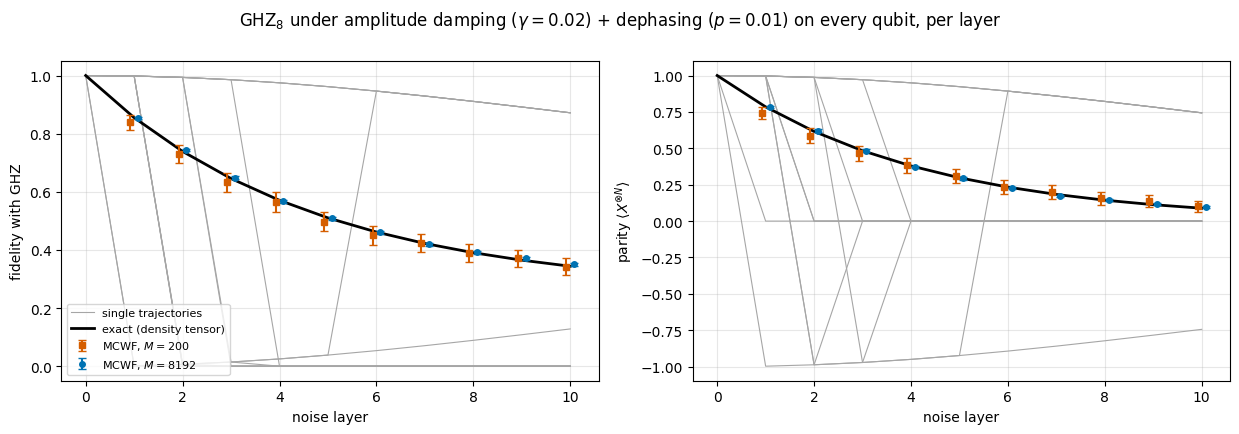

after 10 layers: exact F = 0.3439, MCWF F = 0.3501 +- 0.0044;  exact parity = 0.0885, MCWF = 0.0975 +- 0.0063


In [36]:
# ==============================================================================
# FIGURE: single trajectories, their average, and the exact density-tensor result
# ==============================================================================
layers = np.arange(1, n_layers + 1)
layers0 = np.arange(0, n_layers + 1)                            # including the noiseless initial state (F = parity = 1)
with_start = lambda a: np.concatenate([np.ones(1), np.asarray(a)])
M_small = 200                                                   # a small ensemble, to make the error bars visible
mean_s = jnp.mean(obs_traj[:M_small], axis=0)
se_s = jnp.std(obs_traj[:M_small], axis=0) / np.sqrt(M_small)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
for ax, j, lab in [(axes[0], 0, r"fidelity with GHZ"), (axes[1], 1, r"parity $\langle X^{\otimes N}\rangle$")]:
    for i in range(12):
        ax.plot(layers0, with_start(obs_traj[i, :, j]), color="0.65", lw=0.8, label="single trajectories" if i == 0 else None)
    ax.plot(layers0, with_start(obs_exact[:, j]), color="k", lw=2, label="exact (density tensor)")
    ax.errorbar(layers - 0.08, mean_s[:, j], yerr=se_s[:, j], fmt="s", ms=4, color=COLORS[1], capsize=3,
                label=f"MCWF, $M={M_small}$")
    ax.errorbar(layers + 0.08, mean[:, j], yerr=se[:, j], fmt="o", ms=4, color=COLORS[0], capsize=3,
                label=f"MCWF, $M={M_traj}$")
    ax.set_xlabel("noise layer"); ax.set_ylabel(lab)
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle(rf"GHZ$_{N_traj_demo}$ under amplitude damping ($\gamma={gamma_layer}$) + dephasing ($p={p_layer}$) on every qubit, per layer", y=1.0)
fig.tight_layout(); plt.show()
print(f"after {n_layers} layers: exact F = {float(obs_exact[-1, 0]):.4f}, MCWF F = {float(mean[-1, 0]):.4f} +- {float(se[-1, 0]):.4f};"
      f"  exact parity = {float(obs_exact[-1, 1]):.4f}, MCWF = {float(mean[-1, 1]):.4f} +- {float(se[-1, 1]):.4f}")

**Interpretation.** Grey lines are individual trajectories, and three kinds of events can be read off them. (i) Between
jumps the curves drift slowly: the no-jump operator $K_0$ of amplitude damping keeps shrinking the $|1\dots1\rangle$
amplitude. (ii) A *dephasing* jump ($Z_q$) flips the relative sign of the two GHZ components: the parity changes sign and
the fidelity drops to almost zero; a second such jump restores both. (iii) An *emission* jump ($K_1$) collapses the cat
to a product state: the parity is exactly zero from then on, and so is the fidelity (it could return, to ½, only if
every remaining excited qubit also emitted). None of the grey lines resembles
the smooth black curve, yet their average does: the blue points (all trajectories) sit on the exact result with error
bars smaller than the symbols, and the orange points ($M=200$) scatter around it consistently with their larger error bars.
The largest deviation of the full ensemble is 1.43 SE over all layers and both observables, while a reference computed
with the dephasing convention misread as $\rho_{01}\to(1-p)\rho_{01}$ per layer is rejected at 20 SE.

### 11.6 Convergence: the $1/\sqrt M$ law

We now use the $2^{13}$ trajectories to measure the statistical error of the final-layer fidelity as a function of
$M$ in two ways:

* the error of **one** estimate from the first $M$ trajectories, with its error bar (what you have in practice);
* the **root-mean-square error over independent blocks** of size $M$ (we have $2^{13}/M$ of them), which averages out
  the luck of a single estimate and should follow $\sigma/\sqrt M$ closely (the error law of simple Monte-Carlo integration, Press *et al.* 2007, §7.7).

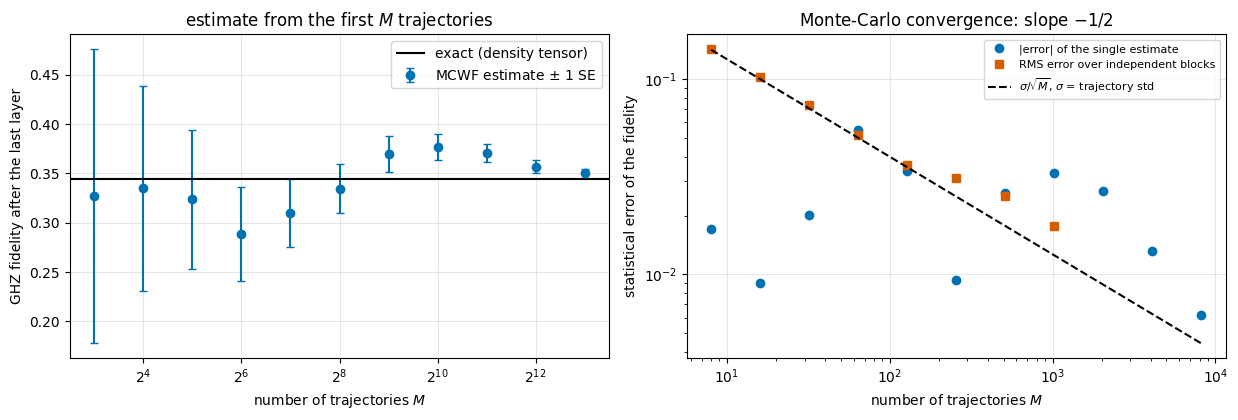

single-trajectory std sigma = 0.4002;  fitted slope of the RMS error (block sizes with >= 32 blocks) = -0.455  (expected -0.5)
block size M                 : [   8   16   32   64  128  256  512 1024]
number of blocks             : [1024  512  256  128   64   32   16    8]
RMS error / (sigma/sqrt(M))  : [1.01 1.02 1.05 1.04 1.03 1.25 1.42 1.41]
grand mean of all 8192 trajectories = 0.3501, exact = 0.3439: offset = +1.40 SE of the full sample
RMS about the grand mean / (sigma/sqrt(M)): [1.01 1.02 1.04 1.03 1.02 1.22 1.38 1.32]
left panel: the 1-SE error bar covers the exact value at 5 of 11 (nested) estimates


In [37]:
# ==============================================================================
# FIGURE: convergence of the trajectory average with the number of trajectories M
# ==============================================================================
f_final = obs_traj[:, -1, 0]                                   # final-layer fidelity of every trajectory
f_exact = float(obs_exact[-1, 0])
sigma = float(jnp.std(f_final))                                # single-trajectory standard deviation
Ms = 2 ** np.arange(3, int(np.log2(M_traj)) + 1)

est = np.array([float(jnp.mean(f_final[:m])) for m in Ms])
est_se = np.array([float(jnp.std(f_final[:m])) / np.sqrt(m) for m in Ms])
rms, rms_M = [], []
for m in Ms[:-3]:                                              # at least 8 independent blocks
    blocks = jnp.mean(f_final.reshape(-1, m), axis=1)
    rms.append(float(jnp.sqrt(jnp.mean((blocks - f_exact) ** 2)))); rms_M.append(m)
rms, rms_M = np.array(rms), np.array(rms_M)
n_blocks = M_traj // rms_M

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
ax1.errorbar(Ms, est, yerr=est_se, fmt="o", color=COLORS[0], capsize=3, label="MCWF estimate $\\pm$ 1 SE")
ax1.axhline(f_exact, color="k", lw=1.5, label="exact (density tensor)")
ax1.set_xscale("log", base=2); ax1.set_xlabel("number of trajectories $M$"); ax1.set_ylabel("GHZ fidelity after the last layer")
ax1.set_title("estimate from the first $M$ trajectories"); ax1.legend()

ax2.loglog(Ms, np.abs(est - f_exact), "o", color=COLORS[0], label="|error| of the single estimate")
ax2.loglog(rms_M, rms, "s", color=COLORS[1], label="RMS error over independent blocks")
ax2.loglog(Ms, sigma / np.sqrt(Ms), "k--", label=r"$\sigma/\sqrt{M}$, $\sigma$ = trajectory std")
ax2.set_xlabel("number of trajectories $M$"); ax2.set_ylabel("statistical error of the fidelity")
ax2.set_title(r"Monte-Carlo convergence: slope $-1/2$"); ax2.legend(fontsize=8)
fig.tight_layout(); plt.show()

good = n_blocks >= 32                                           # an RMS over few blocks is itself a noisy number
slope = np.polyfit(np.log(rms_M[good]), np.log(rms[good]), 1)[0]
print(f"single-trajectory std sigma = {sigma:.4f};  fitted slope of the RMS error (block sizes with >= 32 blocks) = {slope:.3f}  (expected -0.5)")
print(f"block size M                 : {rms_M}")
print(f"number of blocks             : {n_blocks}")
print(f"RMS error / (sigma/sqrt(M))  : {np.round(rms / (sigma / np.sqrt(rms_M)), 2)}")
# the RMS about the exact value splits EXACTLY into the scatter of the blocks about their common mean (= the grand mean of
# all M_traj trajectories) and the offset of that grand mean from the exact value, which every block inherits:
#   mean_b (b - f_exact)^2 = mean_b (b - g)^2 + (g - f_exact)^2,   g = grand mean
g_mean = float(jnp.mean(f_final))
offset_se = (g_mean - f_exact) / (sigma / np.sqrt(M_traj))
rms_g = np.array([float(jnp.sqrt(jnp.mean((jnp.mean(f_final.reshape(-1, m), axis=1) - g_mean) ** 2))) for m in rms_M])
print(f"grand mean of all {M_traj} trajectories = {g_mean:.4f}, exact = {f_exact:.4f}: offset = {offset_se:+.2f} SE of the full sample")
print(f"RMS about the grand mean / (sigma/sqrt(M)): {np.round(rms_g / (sigma / np.sqrt(rms_M)), 2)}")
n_cover = int(np.sum(np.abs(est - f_exact) <= est_se))
print(f"left panel: the 1-SE error bar covers the exact value at {n_cover} of {len(Ms)} (nested) estimates")
assert abs(slope + 0.5) < 0.1
assert abs(slope + 1.0) > 0.3                                   # wrong control: a 1/M law is rejected by the fit

**Interpretation.** Left: the estimates converge to the exact value. The one-sigma error bars cover it at 5 of the 11
points, fewer than the two thirds expected for independent estimates, but these estimates are nested (each contains the
trajectories of the previous one) and therefore share their fluctuations: the full sample of 8192 trajectories lies
$+1.40$ SE above the exact value, and the last five points, which consist mostly of the same trajectories, sit above it
too. Right, on log–log axes: the block-RMS error (orange squares) follows the
line $\sigma/\sqrt M$ with a fitted slope close to $-\tfrac12$, while a *single* estimate (blue dots) fluctuates around and
below the line, as any one draw of a random variable does. The printed ratios drift away from 1 at the three largest
block sizes, and the printout separates the two reasons. The mean square error about the exact value $f$ splits exactly,
$\overline{(b-f)^2}=\overline{(b-g)^2}+(g-f)^2$, where $b$ runs over the block means and $g$ is their common mean, the
grand mean of all trajectories. Every block inherits the offset $g-f$ of the grand mean, which adds
$1.40^2\,M/8192$ to the squared ratio: $0.12$ at $M=512$ and $0.25$ at $M=1024$. The larger part comes from the
scatter about $g$ (ratios 1.22, 1.38, 1.32): an RMS over only $n=32$, 16 and 8 blocks is itself a noisy number, with a
relative uncertainty of about $1/\sqrt{2n}=0.13$, 0.18 and 0.25, and the three values are correlated because they are
built from the same trajectories. This is also why the fit uses only block sizes with at least 32 blocks; its slope is
$-0.455$, and a $1/M$ law (slope $-1$) is rejected. The practical rule follows: **to gain one more decimal digit you need
100 times more trajectories.** Trajectories therefore suit answers at the 1 %–0.1 % level; ten-digit accuracy is out of
their reach. The $N$ dependence enters only through the cost of one trajectory, to which we now turn.

## 12. Cost: $4^N$ against $M\cdot2^N$

### 12.1 Memory

| | density tensor | one trajectory | $M$ trajectories in one `vmap` batch |
|---|---|---|---|
| numbers stored | $4^N$ | $2^N$ | $M\,2^N$ |
| one single-qubit channel | $O(4^N)$ (the $M_K$ Kraus operators are summed first, §12.3) | $O(2^N)$ | $O(M\,2^N)$ |

The break-even point "same memory" is $M=2^N$ trajectories. Already at $N=14$ this is $16\,384$ trajectories, more than
one typically needs. Beyond $N\approx13$–$14$ the density tensor does not fit into a laptop's memory (§5), while single
state vectors remain comfortable up to $N\approx25$–$30$. The table is computed below for the precision chosen in the
configuration cell.

In [38]:
# ==============================================================================
# MEMORY TABLE: density tensor (4^N) versus state vector (2^N)
# ==============================================================================
def human(nbytes):
    for unit in ("B", "KB", "MB", "GB", "TB", "PB"):
        if nbytes < 1000:
            return f"{nbytes:7.1f} {unit}"
        nbytes /= 1000
    return f"{nbytes:7.1f} EB"

itemsize = jnp.zeros((), dtype=CDTYPE).dtype.itemsize
print(f"bytes per amplitude: {itemsize}\n")
print(f"{'N':>3s} | {'density tensor 4^N':>20s} | {'state vector 2^N':>18s} | {'100 trajectories':>18s}")
for n in (4, 8, 10, 12, 14, 16, 20, 24, 28):
    print(f"{n:>3d} | {human(itemsize * 4 ** n):>20s} | {human(itemsize * 2 ** n):>18s} | {human(100 * itemsize * 2 ** n):>18s}")

bytes per amplitude: 16

  N |   density tensor 4^N |   state vector 2^N |   100 trajectories
  4 |               4.1 KB |            256.0 B |            25.6 KB
  8 |               1.0 MB |             4.1 KB |           409.6 KB
 10 |              16.8 MB |            16.4 KB |             1.6 MB
 12 |             268.4 MB |            65.5 KB |             6.6 MB
 14 |               4.3 GB |           262.1 KB |            26.2 MB
 16 |              68.7 GB |             1.0 MB |           104.9 MB
 20 |              17.6 TB |            16.8 MB |             1.7 GB
 24 |               4.5 PB |           268.4 MB |            26.8 GB
 28 |               1.2 EB |             4.3 GB |           429.5 GB


### 12.2 Measured timings

**Experiment.** $|{+}\rangle^{\otimes N}$ with dephasing $p=0.2$ on the first and the last qubit; we measure the Bloch
components of those two qubits. Exact result: $\langle X\rangle=1-2p=0.6$, $\langle Y\rangle=\langle Z\rangle=0$, for every
$N$. We run the density tensor while it fits comfortably ($N\le10$ here) and $M=100$ trajectories up to $N=20$, where
the density tensor would need 17.6 TB.

> **JAX practice.** `vmap` over 100 trajectories of $2^{20}$ amplitudes would allocate all of them (and the einsum
> intermediates) at once. `lax.map(f, keys, batch_size=b)` is the memory-bounded alternative: it vmaps over chunks of
> `b` keys and loops over the chunks sequentially. Timing follows the rules of notebook 01: call once to compile, then
> time a second call and wait for the result with `block_until_ready()`.

> **JAX practice.** The initial state is passed to the jitted functions as an *argument*. Had we built it inside, the
> function would have no array input at all, and XLA would try to evaluate the whole computation at compile time
> ("constant folding"), which is slow for large arrays and makes the run-time measurement meaningless.

> **Numerical practice.** The qubit labels define the einsum string, so every $N$ is a separate compilation. Compile
> times grow mildly with the tensor rank; run times grow like $4^N$ and $2^N$ respectively.

In [39]:
# ==============================================================================
# PARAMETERS
# ==============================================================================
p_bench = 0.2
M_bench = 100
sizes_dm = (4, 6, 8, 10)
sizes_mc = (4, 8, 12, 16, 20)

# ==============================================================================
# STEP 15: benchmark -- density tensor versus trajectories, compile time and run time separately
# ==============================================================================
def timed(fn, *args):
    """(result, time of first call incl. compilation, time of second call) with proper synchronisation."""
    t0 = time.perf_counter(); out = jax.block_until_ready(fn(*args)); t_first = time.perf_counter() - t0
    t0 = time.perf_counter(); out = jax.block_until_ready(fn(*args)); t_run = time.perf_counter() - t0
    return out, t_first, t_run


def make_dm_run(N):
    def run(psi0):
        rho = to_dm(psi0)
        for q in (0, N - 1):
            rho = apply_kraus_dm(rho, kraus_dephasing(p_bench), [q])
        return jnp.stack([expect_local_dm(rho, P, [q]) for q in (0, N - 1) for P in (X, Y, Z)])
    return jax.jit(run)


def make_mcwf_run(N, batch):
    def one(key, psi):
        for q, k in zip((0, N - 1), jax.random.split(key, 2)):
            psi = apply_kraus_mcwf(k, psi, kraus_dephasing(p_bench), [q])
        r_first, r_last = rdm(psi, [0]), rdm(psi, [N - 1])
        return jnp.real(jnp.stack([jnp.trace(r @ P) for r in (r_first, r_last) for P in (X, Y, Z)]))
    return jax.jit(lambda psi0, keys: lax.map(lambda k: one(k, psi0), keys, batch_size=batch))


exact_vals = np.array([1 - 2 * p_bench, 0, 0, 1 - 2 * p_bench, 0, 0])
bench_dm, bench_mc, x_est = {}, {}, []
print(f"{'N':>3s} | {'method':14s} | {'<X_0>':>16s} {'<Z_0>':>16s} {'<X_N-1>':>16s} | {'compile+run [s]':>15s} {'run [s]':>9s}")
for N in sizes_dm:
    vals, t_first, t_run = timed(make_dm_run(N), product_state("+" * N))
    bench_dm[N] = t_run
    assert float(jnp.max(jnp.abs(vals - exact_vals))) < 100 * TOL
    print(f"{N:>3d} | {'density tensor':14s} | {float(vals[0]):>+16.4f} {float(vals[2]):>+16.4f} {float(vals[3]):>+16.4f} | {t_first:>15.3f} {t_run:>9.4f}")
for N in sizes_mc:
    keys = jax.random.split(jax.random.PRNGKey(1000 + N), M_bench)
    vals, t_first, t_run = timed(make_mcwf_run(N, batch=10 if N >= 16 else M_bench), product_state("+" * N), keys)
    bench_mc[N] = t_run
    mean, se = np.asarray(jnp.mean(vals, axis=0)), np.asarray(jnp.std(vals, axis=0)) / np.sqrt(M_bench)
    assert np.all(np.abs(mean - exact_vals) <= 4.5 * se + 1e3 * TOL)
    cells = [f"{mean[i]:+.3f}±{se[i]:.3f}" for i in (0, 2, 3)]
    print(f"{N:>3d} | {f'MCWF, M={M_bench}':14s} | {cells[0]:>16s} {cells[1]:>16s} {cells[2]:>16s} | {t_first:>15.3f} {t_run:>9.4f}")
    x_est += [(mean[i], se[i]) for i in (0, 3)]

# pooled test of the 10 independent <X> estimates (two qubits x five sizes), with a wrong control
x_m, x_se = np.array([m for m, _ in x_est]), np.array([s for _, s in x_est])
pooled, pooled_se = np.mean(x_m), np.sqrt(np.sum(x_se ** 2)) / len(x_m)
z_ok, z_wrong = (pooled - (1 - 2 * p_bench)) / pooled_se, (pooled - (1 - p_bench)) / pooled_se
print(f"\nall {len(x_m)} <X> estimates: largest single deviation {np.max(np.abs(x_m - (1 - 2 * p_bench)) / x_se):.2f} SE; "
      f"pooled <X> = {pooled:.4f} +- {pooled_se:.4f}")
print(f"pooled deviation from 1 - 2p = {1 - 2 * p_bench:.1f}: {z_ok:+.2f} SE;  from the misread 1 - p = {1 - p_bench:.1f}: {z_wrong:+.1f} SE")
assert abs(z_ok) < 4.5 and abs(z_wrong) > 4.5

  N | method         |            <X_0>            <Z_0>          <X_N-1> | compile+run [s]   run [s]


  4 | density tensor |          +0.6000          +0.0000          +0.6000 |           0.086    0.0002


  6 | density tensor |          +0.6000          +0.0000          +0.6000 |           0.099    0.0002


  8 | density tensor |          +0.6000          +0.0000          +0.6000 |           0.122    0.0009


 10 | density tensor |          +0.6000          +0.0000          +0.6000 |           0.169    0.0161


  4 | MCWF, M=100    |     +0.640±0.077     +0.000±0.000     +0.680±0.073 |           0.295    0.0004


  8 | MCWF, M=100    |     +0.720±0.069     +0.000±0.000     +0.680±0.073 |           0.298    0.0009


 12 | MCWF, M=100    |     +0.580±0.081     +0.000±0.000     +0.560±0.083 |           0.285    0.0086


 16 | MCWF, M=100    |     +0.520±0.085     +0.000±0.000     +0.580±0.081 |           0.409    0.1114


 20 | MCWF, M=100    |     +0.520±0.085     +0.000±0.000     +0.540±0.084 |           2.465    2.1396

all 10 <X> estimates: largest single deviation 1.73 SE; pooled <X> = 0.6020 +- 0.0252
pooled deviation from 1 - 2p = 0.6: +0.08 SE;  from the misread 1 - p = 0.8: -7.9 SE


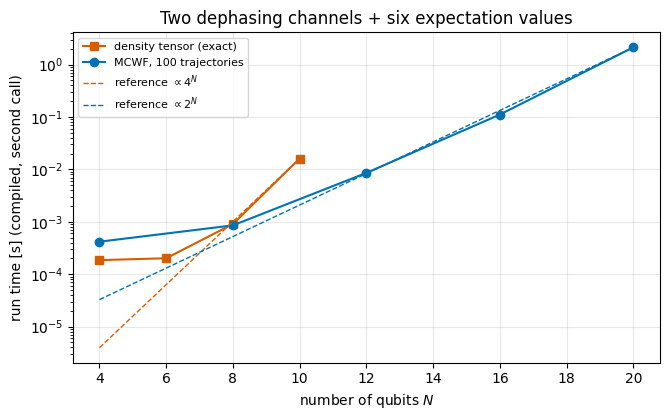

In [40]:
# ==============================================================================
# FIGURE: measured run time versus N
# ==============================================================================
fig, ax = plt.subplots(figsize=(6.8, 4.3))
n_dm, n_mc = np.array(sizes_dm), np.array(sizes_mc)
ax.semilogy(n_dm, [bench_dm[n] for n in n_dm], "s-", color=COLORS[1], label="density tensor (exact)")
ax.semilogy(n_mc, [bench_mc[n] for n in n_mc], "o-", color=COLORS[0], label=f"MCWF, {M_bench} trajectories")
ax.semilogy(n_dm, bench_dm[n_dm[-1]] * 4.0 ** (n_dm - n_dm[-1]), "--", color=COLORS[1], lw=1, label=r"reference $\propto4^N$")
ax.semilogy(n_mc, bench_mc[n_mc[-1]] * 2.0 ** (n_mc - n_mc[-1]), "--", color=COLORS[0], lw=1, label=r"reference $\propto2^N$")
ax.set_xlabel("number of qubits $N$"); ax.set_ylabel("run time [s] (compiled, second call)")
ax.set_title("Two dephasing channels + six expectation values"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Interpretation.** The trajectory estimates scatter around the exact $\langle X\rangle=0.6$ by less than two standard
errors at every $N$ (largest 1.73 SE; with $M=100$ the standard error of a $\pm1$-valued quantity is about $0.08$).
Pooled over the ten independent estimates, $\langle X\rangle=0.602\pm0.025$, which rejects the value $1-p=0.8$ of a
misread dephasing convention by 7.9 standard errors. In addition $\langle Z\rangle=0$ holds
exactly in each trajectory, since a $Z$-flip maps $|+\rangle$ to $|-\rangle$. For small $N$ the run times are dominated by
size-independent overheads (kernel launches, random-number generation) and are almost flat; once the arrays are large
the growth steepens towards the reference slopes $4^N$ and $2^N$, drawn as dashed lines through the last point of each
curve. The individual seconds depend on the machine and on the memory
hierarchy (the largest density tensor here no longer fits in cache, so its time is set by memory bandwidth rather than
by arithmetic, and it can even grow faster than $4^N$). Structurally, the density-tensor curve *cannot be
continued* much beyond $N\approx13$–$14$, where a single copy of $\rho$ needs gigabytes (see the memory table), whereas
the trajectory curve continues to $N\approx25$ and more.

### 12.3 One einsum against a loop over Kraus operators

`apply_kraus_dm` sums over $m$ inside one einsum. The obvious alternative is a Python loop
$\sum_m$ `apply_gate_dm(rho, K[m], q)` (which works because `apply_gate_dm` never assumed unitarity). Under `jit` both
are compiled by XLA, so we decide between them by measuring.

In [41]:
# ==============================================================================
# BENCHMARK: single-einsum Kraus channel versus explicit loop over the Kraus index (both jitted)
# ==============================================================================
def apply_kraus_dm_loop(rho, kraus, qubits):
    """Reference implementation: explicit sum over m of K_m rho K_m^dagger, each term = two `apply_gate` calls."""
    return sum(apply_gate_dm(rho, kraus[m], qubits) for m in range(kraus.shape[0]))


N = 9
rho = to_dm(ghz_state(N))
Kc = kraus_depolarizing(0.1)
layer_einsum = jax.jit(lambda r: apply_kraus_all_dm(r, Kc))
def _layer_loop(r):
    for q in range(N):
        r = apply_kraus_dm_loop(r, Kc, [q])
    return r
layer_loop = jax.jit(_layer_loop)

out_a, tc_a, tr_a = timed(layer_einsum, rho)
out_b, tc_b, tr_b = timed(layer_loop, rho)
err = float(jnp.max(jnp.abs(out_a - out_b)))
print(f"N = {N}, depolarising layer on all qubits (4 Kraus operators each)")
print(f"  one einsum per channel : first call {tc_a:6.3f} s, run {tr_a:.4f} s")
print(f"  loop over m            : first call {tc_b:6.3f} s, run {tr_b:.4f} s")
print(f"  max difference of the results = {err:.1e}")
assert err < TOL

N = 9, depolarising layer on all qubits (4 Kraus operators each)
  one einsum per channel : first call  0.117 s, run 0.0084 s
  loop over m            : first call  0.233 s, run 0.0414 s
  max difference of the results = 1.7e-16


Both give the same density tensor. The timings printed above are from the machine that built this notebook; on
yours they may differ, so treat them as a measurement on one machine. Structurally, the single einsum lets the
contraction planner first combine $K$ and $K^*$ into a tiny $(2,2,2,2)$ "superoperator" $\sum_mK_m\otimes K_m^*$ (16 numbers) and
then perform **one** pass over the $4^N$ entries of $\rho$, independent of the number of Kraus operators, whereas the
loop performs two passes per Kraus operator and accumulates $M_K$ full-size arrays.

## 13. Summary: key takeaways

* A **density operator** $\rho=\sum_kp_k|\psi_k\rangle\langle\psi_k|$ (Hermitian, unit trace, positive) describes both classical
  ignorance and subsystems of entangled states, and the two cannot be told apart locally. Purity, entropy and, for one
  qubit, the length of the Bloch vector measure how mixed it is.
* Numerically, $\rho$ is a **density tensor of rank $2N$**: ket axes $0..N-1$, bra axes $N..2N-1$. Traces are repeated
  letters; a unitary is `apply_gate` with $U$ on ket axes and with $U^*$ on bra axes; the partial transpose is an axis swap.
* Physical noise is a **quantum channel** $\rho\to\sum_mK_m\rho K_m^\dagger$ with $\sum_mK_m^\dagger K_m=\mathbb 1$:
  completely positive (it must map states to states even when the system is half of an entangled pair — transposition
  fails this test) and trace preserving. Kraus operators are slices of a system–environment unitary. A channel on a
  density tensor is **one einsum** in which the Kraus index is summed.
* Bit flip, dephasing, depolarising and amplitude damping contract the **Bloch ball** in characteristic ways; only
  amplitude damping shifts it (and can re-purify a state). Kraus representations are not unique.
* A **GHZ state** loses its $N$-body coherence, its fidelity above ½ and its negativity as $(1-2p)^N$ under local
  dephasing ($N$ times the single-qubit rate), while its classical $ZZ$ correlations survive. One noisy qubit is enough to damage the whole state.
* The **stochastic unravelling** samples one Kraus branch with probability $\|K_m\psi\|^2$ and renormalises; the trajectory
  average equals the channel *exactly* (Eq. 5), for quantities linear in $\rho$. Error $\sigma/\sqrt M$, independent of $N$;
  the variance depends on the Kraus representation.
* **Cost**: $4^N$ (exact, $N\lesssim13$–$14$) against $M\cdot2^N$ (statistical). Trajectories are independent, so they
  need not be held in memory together: one state vector at a time reaches $N\approx25$–$30$, with `jax.vmap` over a
  batch, `lax.map` over batches when memory is tight, and time loops through `lax.scan`.
* Habit: every new contraction was written by hand for small $N$, compared with dense `kron` algebra, and only then
  generalised; every Monte-Carlo result was compared with an exact number in units of its standard error.

**Where this is used next:** measurements as (non-trace-preserving) Kraus operators in
[08 — Measurements](08_measurements.ipynb); noisy circuits in [09 — Quantum gates and circuits](../ch04_digital_quantum_circuits/09_quantum_gates_and_circuits.ipynb);
continuous-time open systems in [16 — Lindblad master equation](../ch06_open_quantum_systems/16_lindblad_master_equation.ipynb) and
[17 — Monte-Carlo wave function](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb) (Chapter 6).

## 14. Exercises

1. ★ **Another ensemble.** Show on paper and numerically (with `dm_from_ensemble`) that the 50/50 mixture of the $Y$
   eigenstates $(|0\rangle\pm i|1\rangle)/\sqrt2$ is again $\mathbb 1/2$. Then find an ensemble of *three* non-orthogonal
   pure states with equal weights whose density matrix is $\mathbb 1/2$. (Hint: think of the Bloch vectors.)
2. ★ **Bit-phase flip.** Write `kraus_bit_phase_flip(p)` with Kraus operators $\sqrt{1-p}\,\mathbb 1,\sqrt p\,Y$. Predict its
   Bloch map from the Pauli-channel formula of §9.3, verify with `bloch_map`, and add a fifth panel to the Bloch-sphere figure.
3. ★★ **$T_1$ and $T_2$ together.** Apply amplitude damping ($\gamma$) followed by dephasing ($p$) $n$ times to $|+\rangle$. Show
   analytically and numerically that $\langle X\rangle_n=[\sqrt{1-\gamma}\,(1-2p)]^n$. With $\gamma=1-e^{-\Delta t/T_1}$ and
   $1-2p=e^{-\Delta t/T_\phi}$ derive the relation $1/T_2=1/(2T_1)+1/T_\phi$ and conclude that $T_2\le2T_1$. Does the
   order of the two channels matter?
4. ★★ **Mixing two channels.** With probability $\eta$ apply amplitude damping towards $|0\rangle$, otherwise amplitude
   damping towards $|1\rangle$. Show that the Kraus operators are $\sqrt{\eta}\,K_0,\sqrt{\eta}\,K_1$ (those of amplitude damping)
   and $\sqrt{1-\eta}\,XK_0X,\sqrt{1-\eta}\,XK_1X$. Implement the channel, check completeness, find its Bloch map and its fixed
   point as a function of $\eta$. For which $\eta$ is the fixed point the maximally mixed state?
5. ★★ **Extend the code: correlated noise.** Build the two-qubit depolarising channel with the 16 Kraus operators
   $\sqrt{1-p}\,\mathbb 1\otimes\mathbb 1$ and $\sqrt{p/15}\,\sigma_i\otimes\sigma_j$ ($(i,j)\ne(0,0)$) as a stack of shape $(16,4,4)$ and
   apply it with `apply_kraus_dm(rho, K, [q1, q2])`. Compare its effect on a Bell pair (fidelity, negativity) with that
   of two independent single-qubit depolarising channels of the same total error probability, i.e. of strength $p_1$
   with $(1-p_1)^2=1-p$, so that "no error at all" has the same probability in both models.
6. ★★ **Robustness of GHZ and W entanglement.** Repeat the sweep of §10 for the W state (`dicke_state(N,1)` in the
   engine, or build it yourself) under dephasing and under amplitude damping. Compare fidelity and the negativity of
   the cut $\{0\}|$rest with the GHZ results. Why does losing one qubit (tracing it out) destroy all entanglement of GHZ but not of W?
7. ★★★ **The best unravelling.** For the dephasing channel, the Kraus sets $K'_m=\sum_nu_{mn}K_n$ with
   $u=\begin{pmatrix}\cos\alpha&\sin\alpha\\-\sin\alpha&\cos\alpha\end{pmatrix}$ all describe the same channel. For the state $|+\rangle$
   and the observable $X$, compute the single-trajectory variance as a function of $\alpha$ (numerically with
   `apply_kraus_mcwf`, then analytically). Which $\alpha$ minimises it, and where do the two unravellings of §11.3 sit?
8. ★★★ **Purity from trajectories without $4^N$ memory.** Show that for two *independent* trajectories $i\ne j$,
   $\mathbb E\,|\langle\psi^{(i)}|\psi^{(j)}\rangle|^2=\mathrm{Tr}\rho^2$. Implement this estimator with `vmap` over pairs of keys
   for the experiment of §11.5, add error bars, and compare with the exact purity from the density tensor.

## 15. References

* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2010):
  chapter 2.4 (density operator, Theorem 2.6 on the unitary freedom in the ensemble), chapter 8 (quantum noise,
  operator-sum representation, Theorem 8.2 on the unitary freedom; the channel zoo of §9 follows its §8.3).
* J. Preskill, *Lecture Notes for Physics 229: Quantum Information and Computation* (Caltech), chapter 3
  "Foundations II: Measurement and evolution" (channels, Kraus representation, master equation).
* H.-P. Breuer and F. Petruccione, *The Theory of Open Quantum Systems* (Oxford University Press, 2002).
* K. Kraus, *States, Effects, and Operations: Fundamental Notions of Quantum Theory*, ed. A. Böhm, J. D. Dollard and
  W. H. Wootters, Lecture Notes in Physics **190** (Springer, 1983).
* W. F. Stinespring, "Positive functions on C\*-algebras", Proc. Amer. Math. Soc. **6**, 211–216 (1955) (the dilation
  theorem behind §7.2).
* J. Dalibard, Y. Castin and K. Mølmer, "Wave-function approach to dissipative processes in quantum optics",
  Phys. Rev. Lett. **68**, 580 (1992).
* H. J. Carmichael, *An Open Systems Approach to Quantum Optics* (Lecture Notes in Physics m18, Springer, 1993).
* M. B. Plenio and P. L. Knight, "The quantum-jump approach to dissipative dynamics in quantum optics",
  Rev. Mod. Phys. **70**, 101 (1998).
* T. Monz *et al.*, "14-qubit entanglement: creation and coherence", Phys. Rev. Lett. **106**, 130506 (2011).
* A. Peres, "Separability criterion for density matrices", Phys. Rev. Lett. **77**, 1413 (1996); G. Vidal and
  R. F. Werner, "Computable measure of entanglement", Phys. Rev. A **65**, 032314 (2002) (negativity).
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific
  Computing*, 3rd ed. (Cambridge University Press, 2007), chapter 7 (random numbers; §7.7 simple Monte-Carlo
  integration, where the $1/\sqrt M$ error law measured in §11.6 is derived).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/